# Documentation de jeux de données 

In [1]:
import polars as pl
from pathlib import Path

from viz.time_series import (
LABELS,
plot_time_series,
plot_compare,
save_fig
)
def find_root(marker: str = "pyproject.toml"):
    p = Path.cwd().resolve()
    for parent in (p, *p.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"{marker} introuvable en remontant depuis {p}")
ROOT = find_root()
OUTPUT = ROOT / "data" / "graphs"
FIG_DIR = ROOT / "caractérisation_manoeuvres"   # figures exportées pour manoeuvres.tex
## Les différents paramètres récupérés via les TLE SpaceTrack (11 paramètres)
print(LABELS.keys())


dict_keys(['sma', 'eccentricity', 'inclination', 'raan', 'arg_perigee', 'mean_anomaly', 'mean_motion', 'period', 'velocity', 'rev_at_epoch', 'bstar'])


# Un dataset labellisé solide
## L'ILRS met a disposition des maneuvres 

Voici ce que contient une ligne du fichier cs2man.txt récupéré en libre accès depuis le site de l'ILRS qui correspond aux manoeuvres du satellite Cryosat-2 Norad 36508 entre 2010 et 2026 :

CRYO2  # Identifiant satellite 

2026 182 19 53 # date début de manoeuvre

2026 182 19 55    # date fin de manoeuvre 

006     # type de paramètres, dans ce cas : $\Delta v_r, \Delta v_u , \Delta v_h, a_r, a_u, a_h , \Delta_a (pred, measured)$ 

1 #nombre de burns 

2026 182 19 54 12.038   # date mediane du burn en Année/Jour/Heure/Minute/Secondes.ms

01.2500000000000e+02  # Durée du boost

-1.8954357500000e-04 # $\Delta v_r $ 

01.4479253750000e-02 #  $\Delta v_u$ , composante clé, variation de vitesse transverse.

01.3338918750000e-04 # $\Delta v_h$


-1.5163486000000e+00 # $a_r$

01.1583403000000e+02 # $a_u$

01.0671135000000e+00  # $a_h$ 

00.0000000000000e+00 
00.0000000000000e+00 
00.0000000000000e+00



## Données historiques de manoeuvres
Via l'API du site de l'ILRS, on récupère des données de manoeuvres réelles.
Par exemple ci-dessous pour le satellite Sentinel 3B, norad 43437
Testons si les données de manoeuvres correspondent à des variations visibles de paramètres orbitaux 

## Premier test : Sentinel 3B, satellite LEO 2018-2026

shape: (163, 15)
┌───────┬───────────────┬───────────────┬───────────────┬───┬───────────┬────────┬────────┬────────┐
│ sat   ┆ maneuver_star ┆ maneuver_end  ┆ burn_epoch    ┆ … ┆ acc_n     ┆ dacc_r ┆ dacc_t ┆ dacc_n │
│ ---   ┆ t             ┆ ---           ┆ ---           ┆   ┆ ---       ┆ ---    ┆ ---    ┆ ---    │
│ str   ┆ ---           ┆ datetime[μs]  ┆ datetime[μs]  ┆   ┆ f64       ┆ f64    ┆ f64    ┆ f64    │
│       ┆ datetime[μs]  ┆               ┆               ┆   ┆           ┆        ┆        ┆        │
╞═══════╪═══════════════╪═══════════════╪═══════════════╪═══╪═══════════╪════════╪════════╪════════╡
│ SEN3B ┆ 2018-04-30    ┆ 2018-04-30    ┆ 2018-04-30    ┆ … ┆ 0.0       ┆ 0.0    ┆ 0.0    ┆ 0.0    │
│       ┆ 09:20:00      ┆ 11:44:00      ┆ 09:20:36      ┆   ┆           ┆        ┆        ┆        │
│ SEN3B ┆ 2018-04-30    ┆ 2018-04-30    ┆ 2018-04-30    ┆ … ┆ 0.0       ┆ 0.0    ┆ 0.0    ┆ 0.0    │
│       ┆ 09:20:00      ┆ 11:44:00      ┆ 11:44:26.752  ┆   ┆           ┆ 

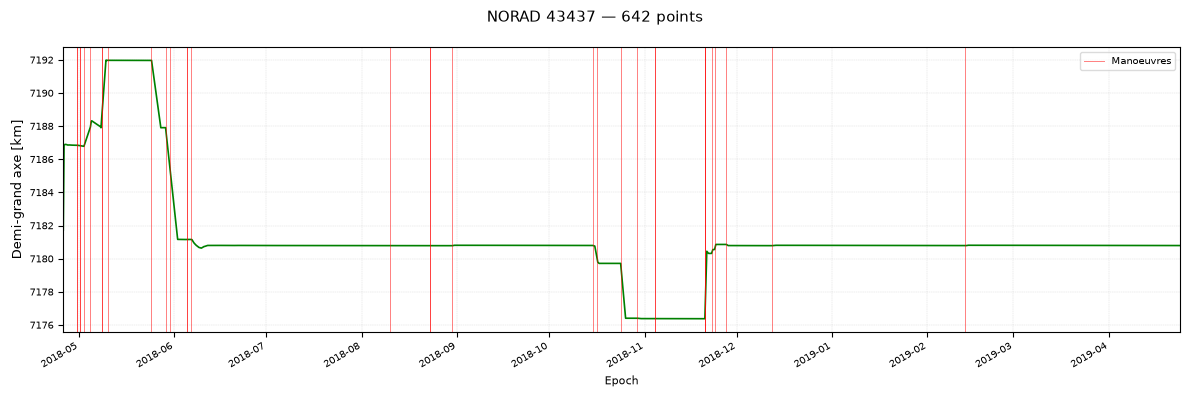

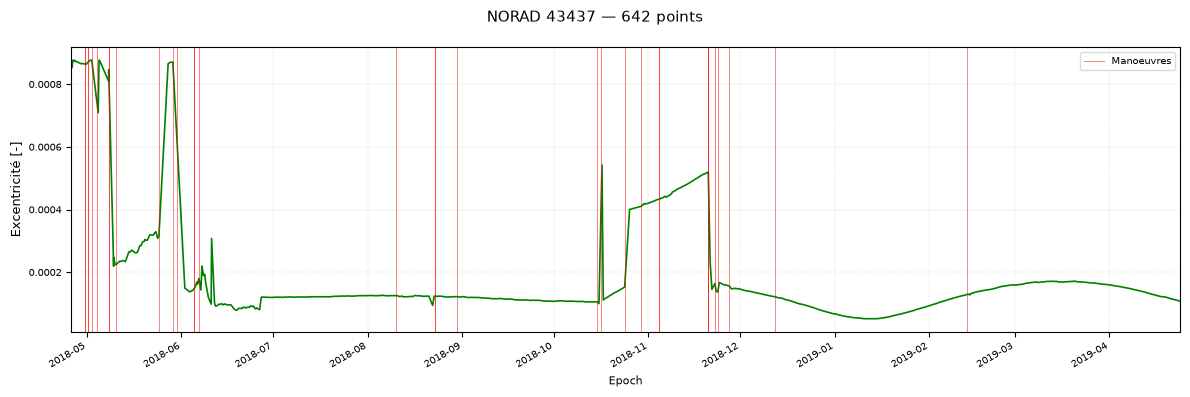

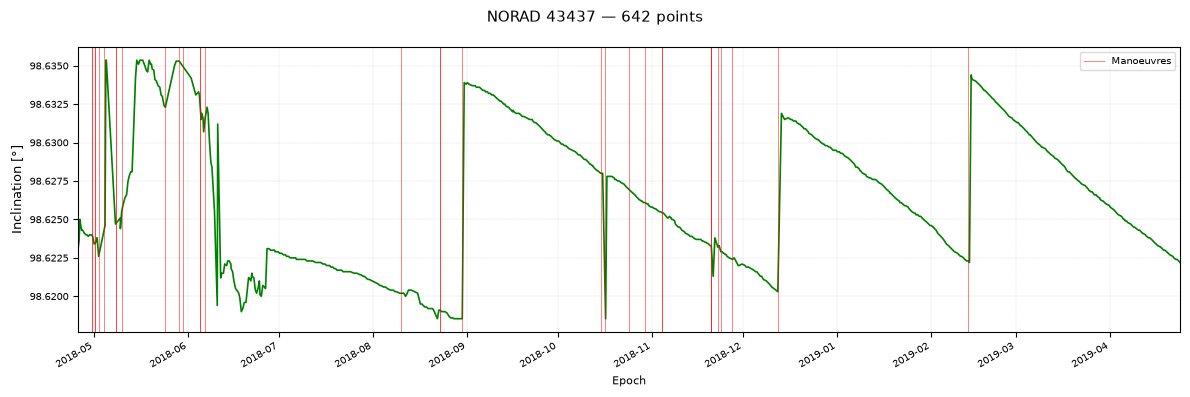

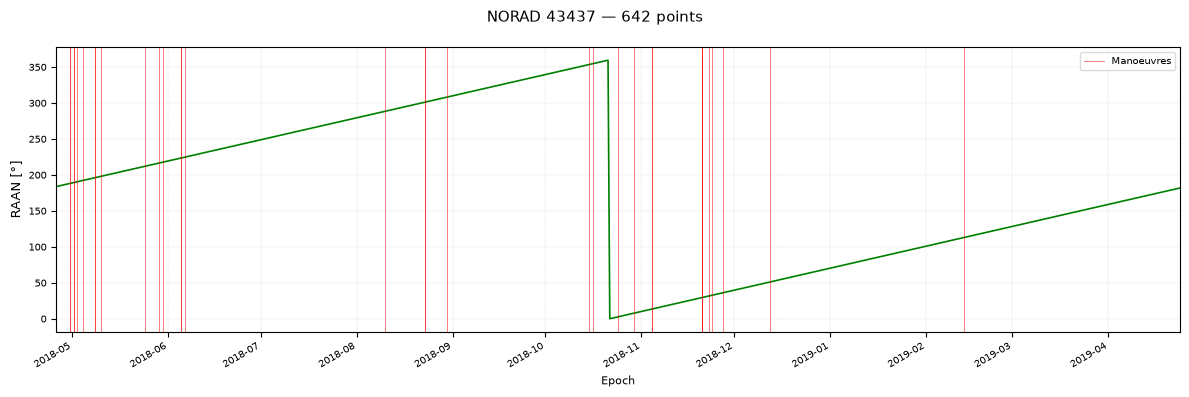

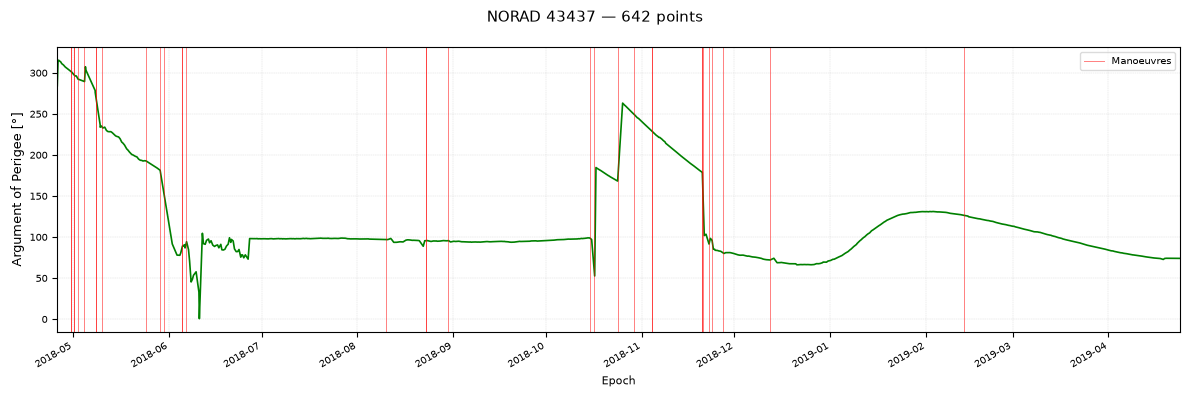

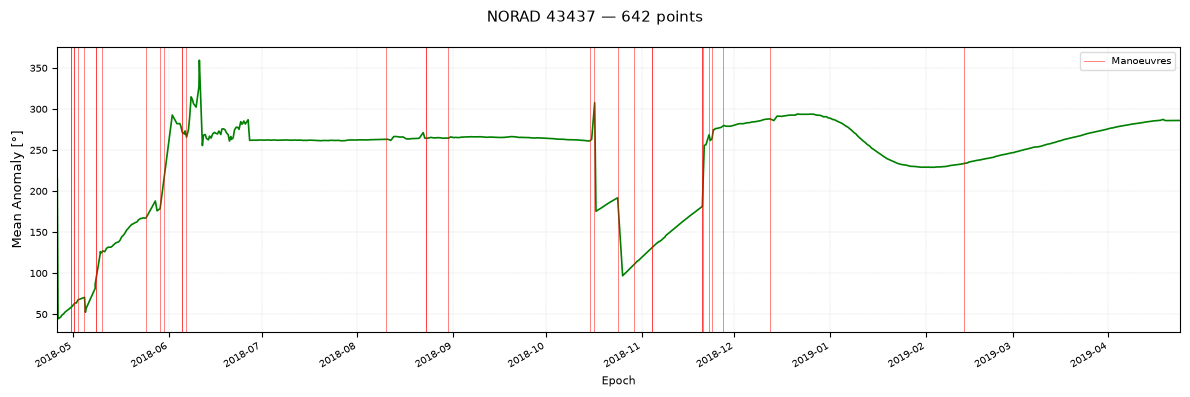

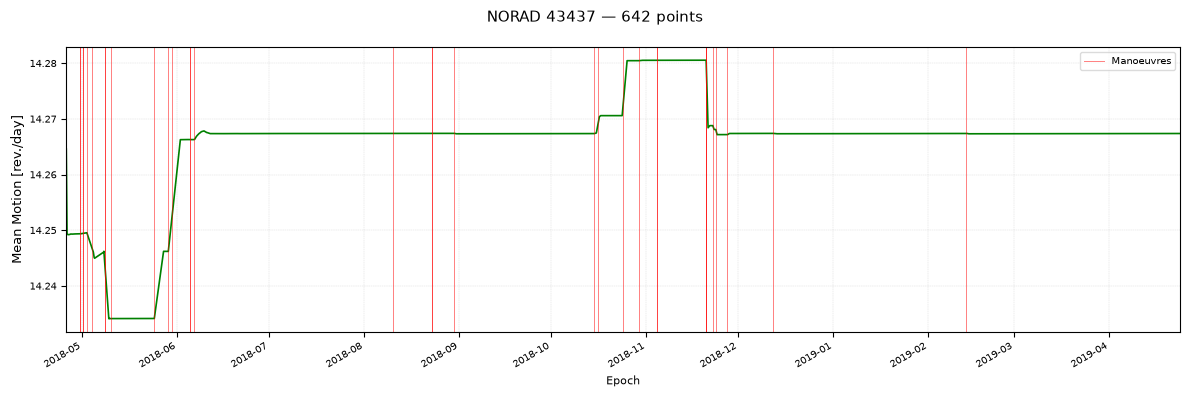

In [2]:
## Les différents paramètres récupérés dans les historiques de manoeuvres 

norad = 43437
path_man_s3b = ROOT / "data" / "raw" / "s3b_man_ILRS.parquet"

df_man_s3b = pl.scan_parquet(path_man_s3b).collect()

print(df_man_s3b)

maneuvers_dates = df_man_s3b.select('maneuver_start').to_series().to_list()

path_TLE_s3b = ROOT / "data" / "raw"  / "SENTINEL_ALL_1783007466.119748.parquet"
for param in ['sma', 'eccentricity', 'inclination', 'raan', 'arg_perigee', 'mean_anomaly', 'mean_motion']:
    fig = plot_time_series(path_TLE_s3b, norad, param, maneuvers=maneuvers_dates)
    fig.savefig(FIG_DIR / f"s3b_{param}.png", dpi=150, bbox_inches="tight")


On voit que certaines manoeuvres étaient clairement visibles à l'oeil nu sur les time-series des paramètres orbitaux, tandis que d'autres manoeuvres ne se détectent pas via un simple regard non-expert sur les paramètres orbitaux.

Regardons l'exemple d'autres satellites.

## ENVISAT - Satellite LEO 2002-2012

shape: (220, 15)
┌───────┬──────────────┬──────────────┬─────────────┬───┬────────────┬────────┬───────────┬────────┐
│ sat   ┆ maneuver_sta ┆ maneuver_end ┆ burn_epoch  ┆ … ┆ acc_n      ┆ dacc_r ┆ dacc_t    ┆ dacc_n │
│ ---   ┆ rt           ┆ ---          ┆ ---         ┆   ┆ ---        ┆ ---    ┆ ---       ┆ ---    │
│ str   ┆ ---          ┆ datetime[μs] ┆ datetime[μs ┆   ┆ f64        ┆ f64    ┆ f64       ┆ f64    │
│       ┆ datetime[μs] ┆              ┆ ]           ┆   ┆            ┆        ┆           ┆        │
╞═══════╪══════════════╪══════════════╪═════════════╪═══╪════════════╪════════╪═══════════╪════════╡
│ ENVI1 ┆ 2002-04-19   ┆ 2002-04-19   ┆ 2002-04-19  ┆ … ┆ 0.0        ┆ 0.0    ┆ -0.029209 ┆ 0.0    │
│       ┆ 04:55:00     ┆ 07:46:00     ┆ 05:55:45.93 ┆   ┆            ┆        ┆           ┆        │
│       ┆              ┆              ┆ 9           ┆   ┆            ┆        ┆           ┆        │
│ ENVI1 ┆ 2002-04-19   ┆ 2002-04-19   ┆ 2002-04-19  ┆ … ┆ 0.0        ┆ 0.0

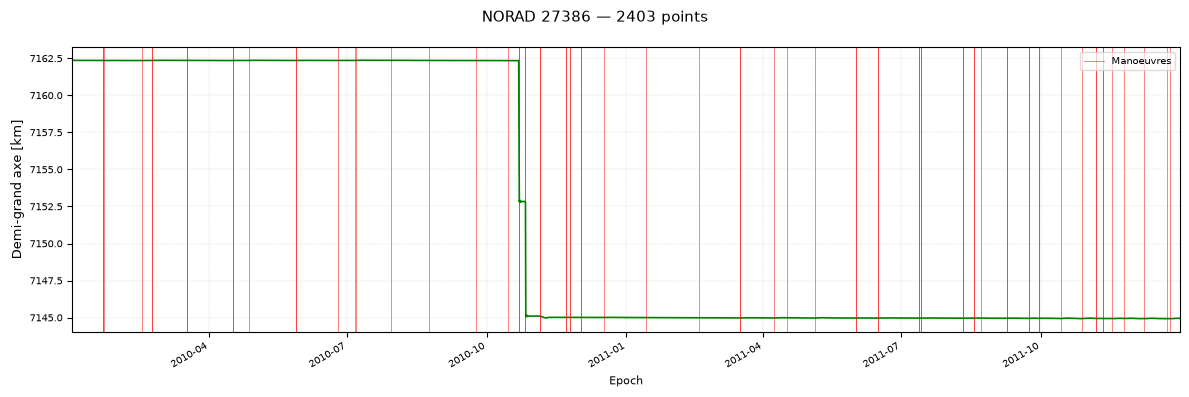

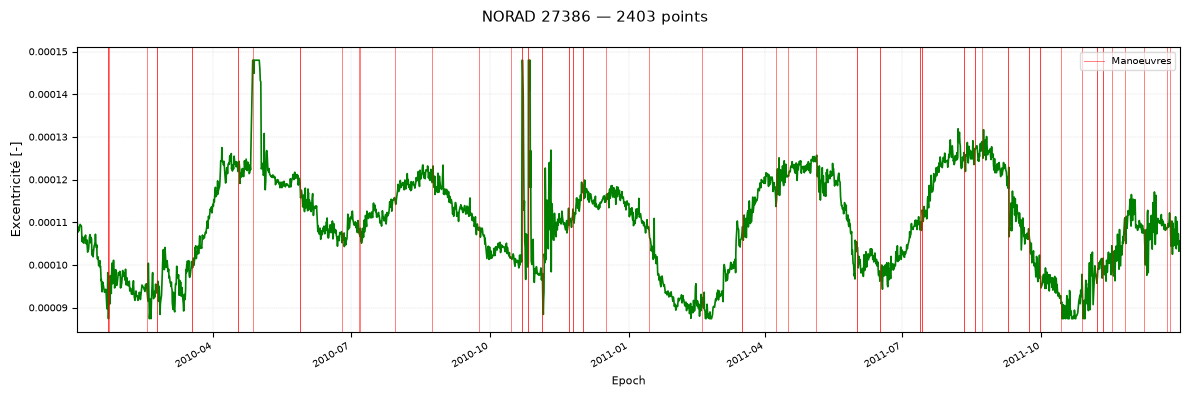

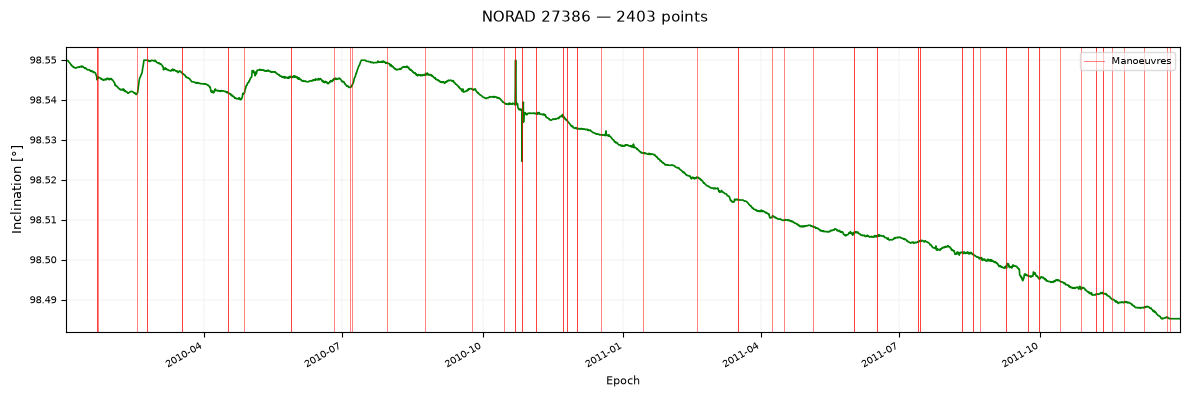

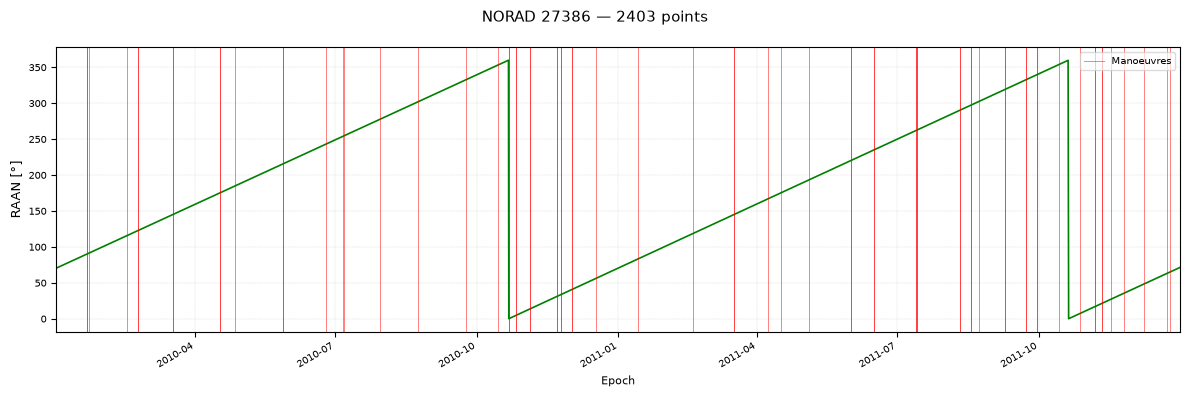

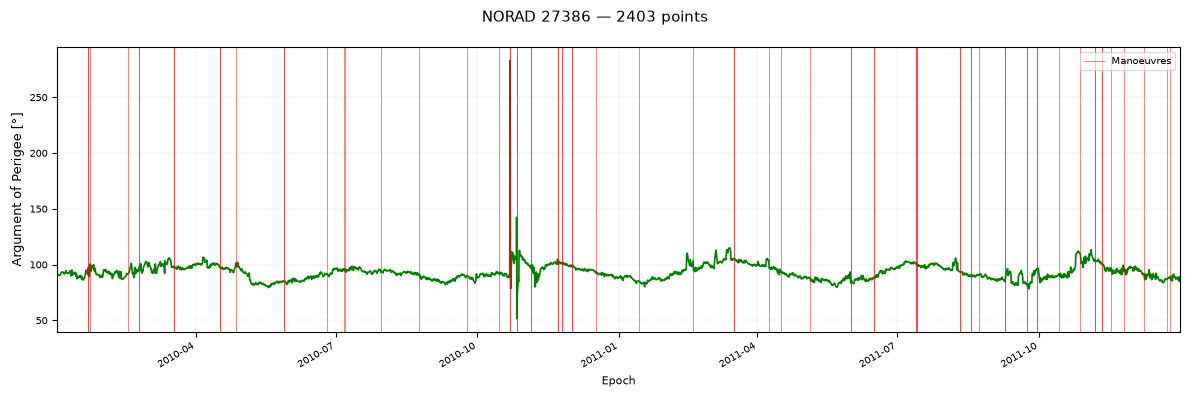

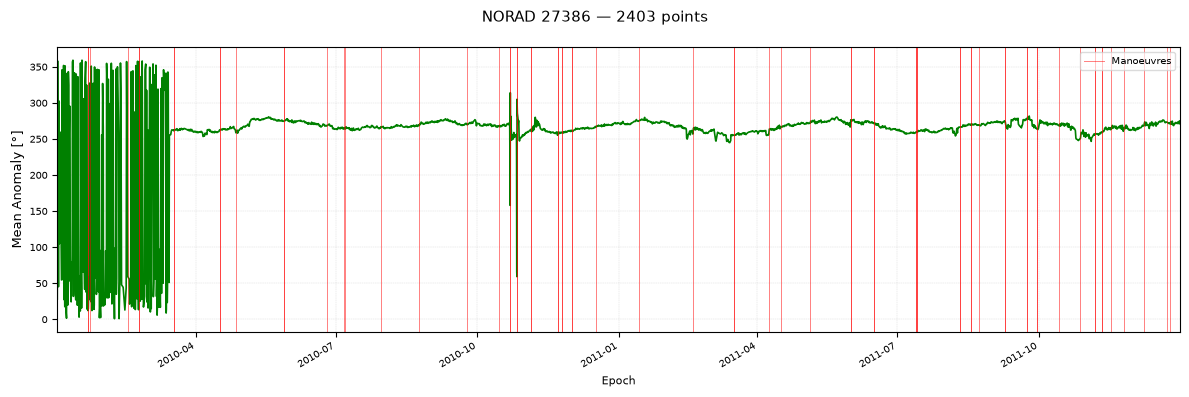

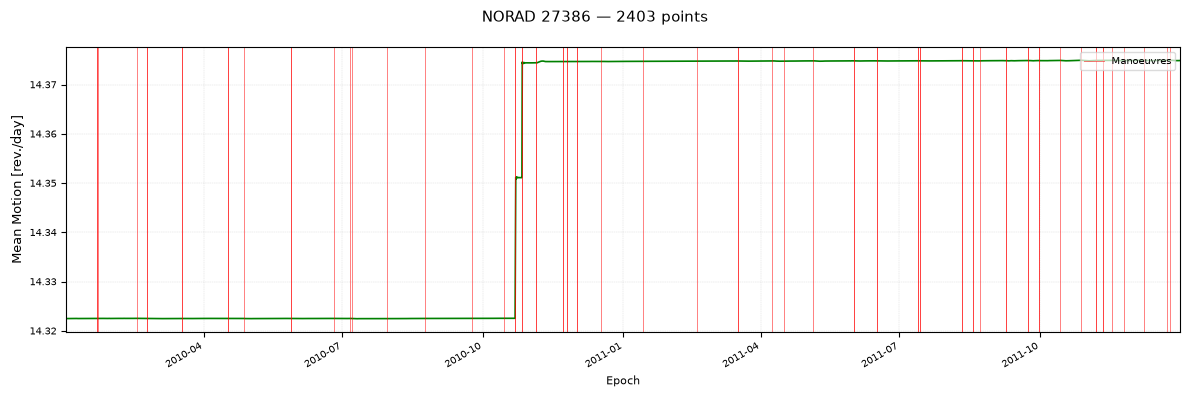

In [3]:
## Les différents paramètres récupérés dans les historiques de manoeuvres 
path_man_en1 = ROOT / "data" / "raw" / "en1_man_ILRS.parquet"
df_man_en1 = pl.scan_parquet(path_man_en1).collect()

print(df_man_en1)

norad = 27386

maneuvers_dates = df_man_en1.select('maneuver_start').to_series().to_list()

path_TLE_en1 = ROOT / "data" / "raw"  / "ENVISAT_ALL_1783068650.78004.parquet"
for param in ['sma', 'eccentricity', 'inclination', 'raan', 'arg_perigee', 'mean_anomaly', 'mean_motion']:
    fig = plot_time_series(path_TLE_en1, norad, param, maneuvers=maneuvers_dates)
    fig.savefig(FIG_DIR / f"en1_{param}.png", dpi=150, bbox_inches="tight")


## Cryosat2 - Satellite LEO 

Norad 36508 in path : True


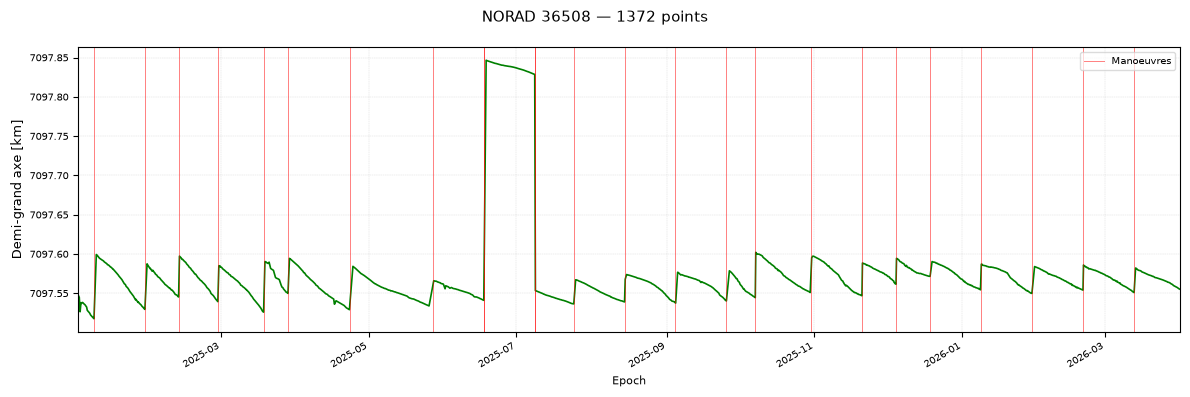

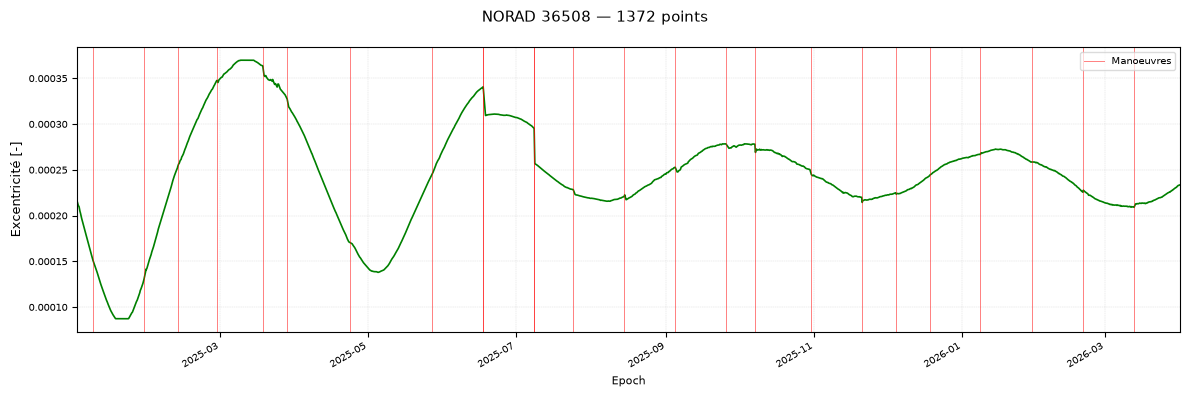

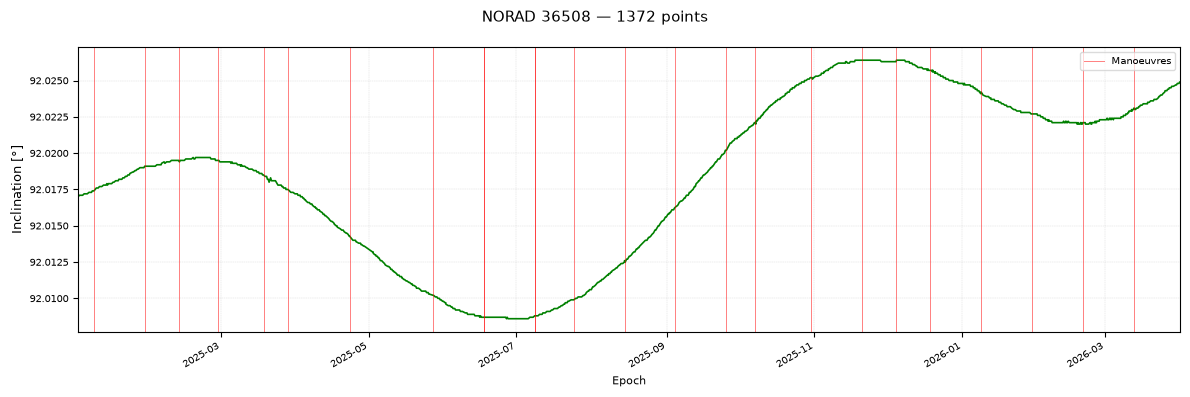

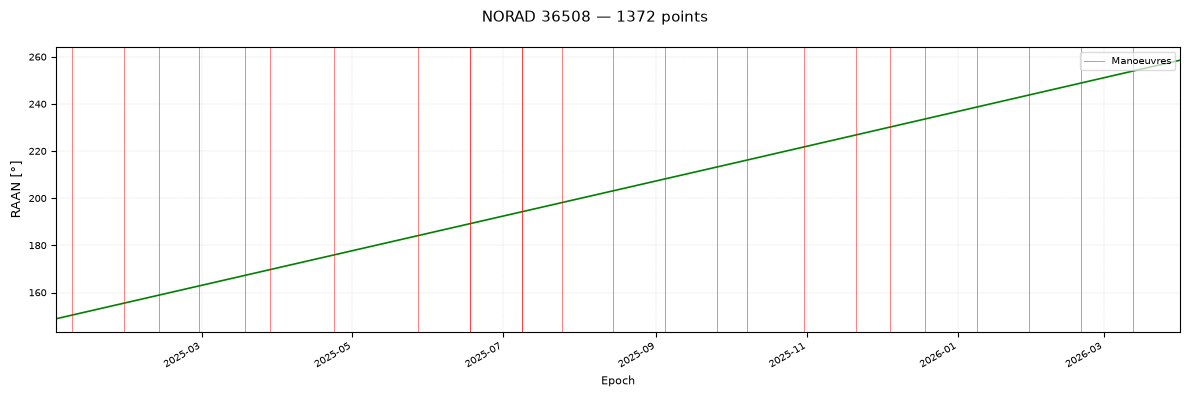

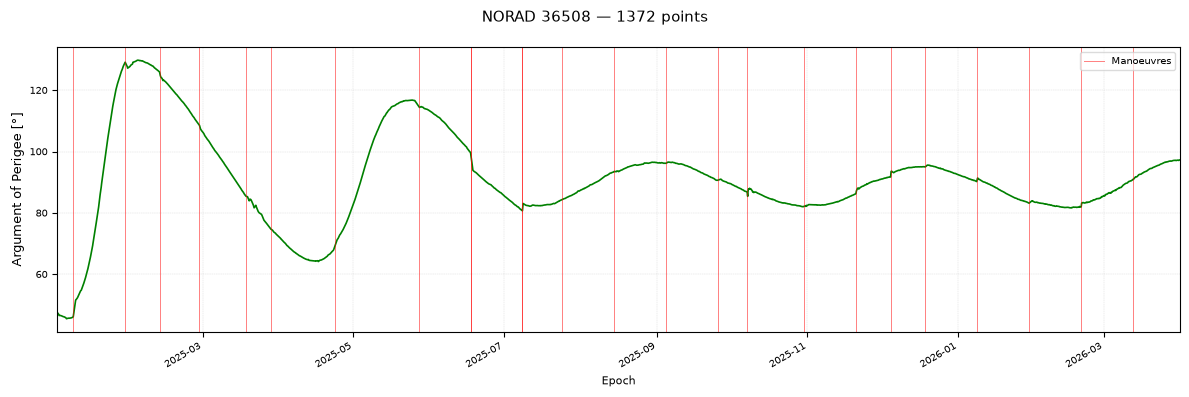

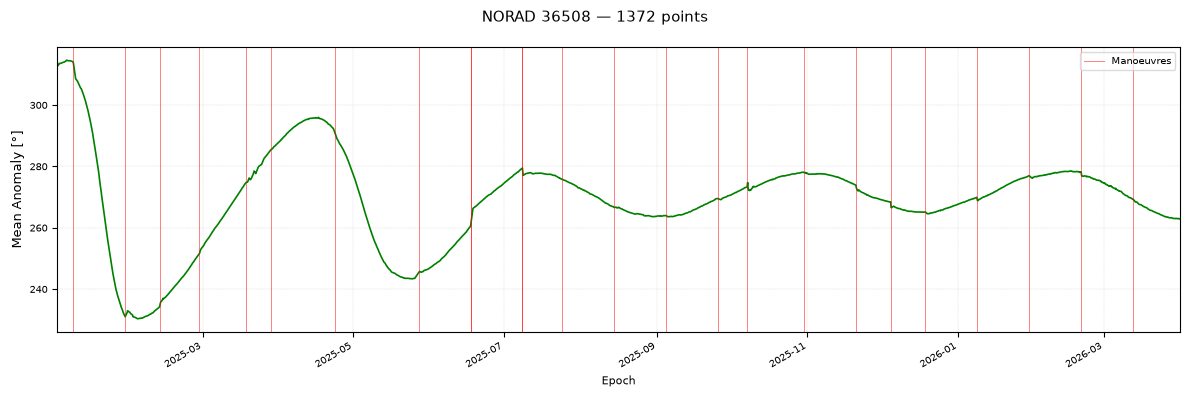

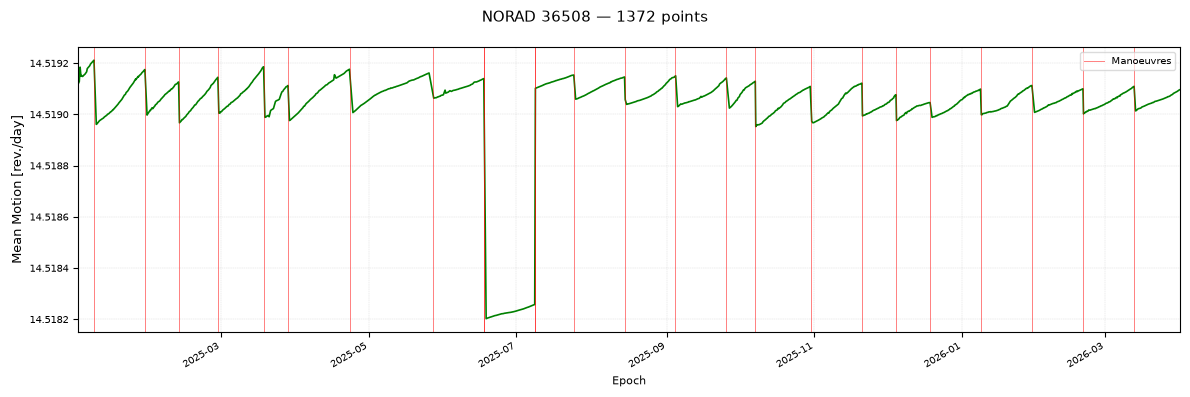

In [4]:

path_TLE_cs2 = ROOT / "data" / "raw" / "CRYOSAT_ESA_1783006097.0149062.parquet"
norads = pl.scan_parquet(path_TLE_cs2).select("norad").unique().sort("norad").collect().to_series().to_list()

norad = 36508
print(f"Norad {norad} in path : {norad in norads}")

path_maneuvers_cs2 = ROOT / "data" / "raw" / "cs2_man_ILRS.parquet"
df_man = pl.scan_parquet(path_maneuvers_cs2).collect()

maneuvers_dates= df_man.select('maneuver_start').to_series().to_list()

df_TLE= (
    pl.scan_parquet(path_TLE_cs2).filter(pl.col('norad') == norad)
    .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
    .sort('epoch').collect()
    )

for param in ['sma', 'eccentricity', 'inclination', 'raan', 'arg_perigee', 'mean_anomaly', 'mean_motion']:
    fig = plot_time_series(path_TLE_cs2, norad, param, maneuvers=maneuvers_dates)
    fig.savefig(FIG_DIR / f"cs2_{param}.png", dpi=150, bbox_inches="tight")


## SARAL - 39086 -  LEO 

Norad 39086 in path : True
Filtre Kalman 1 appliqué...


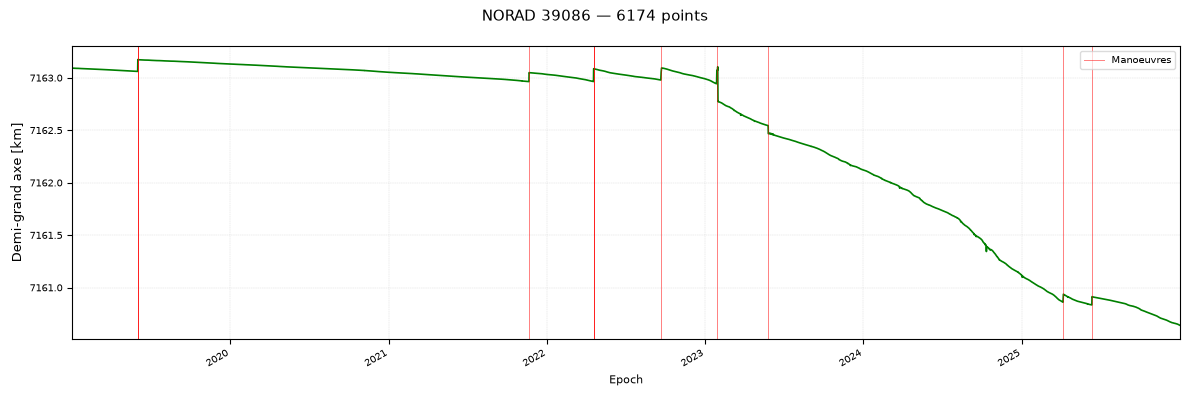

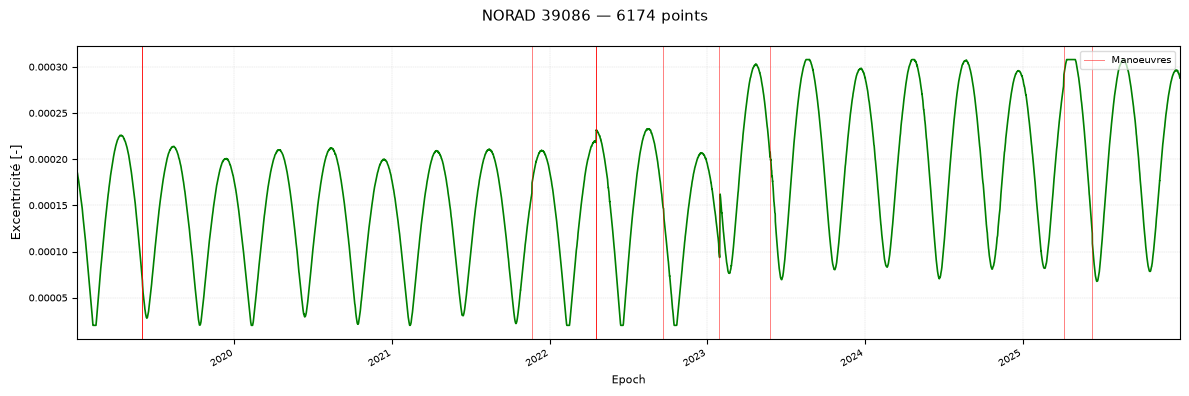

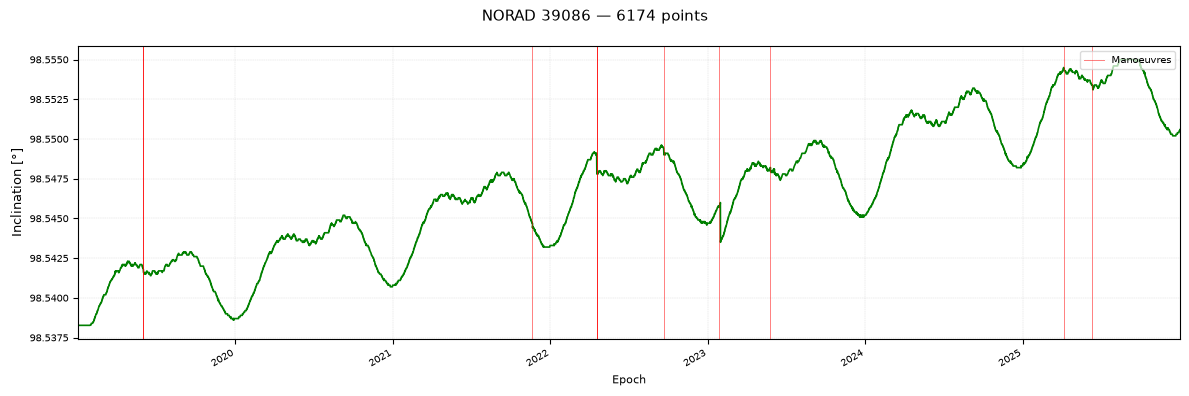

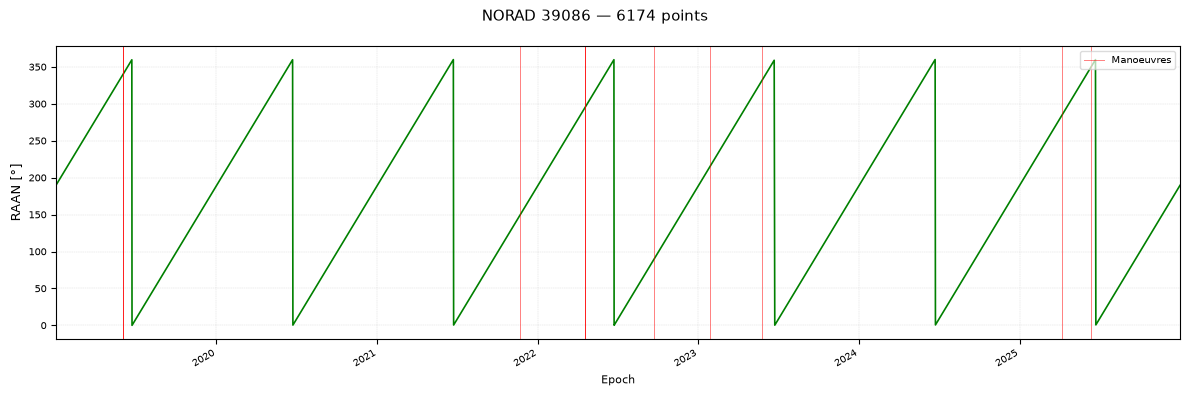

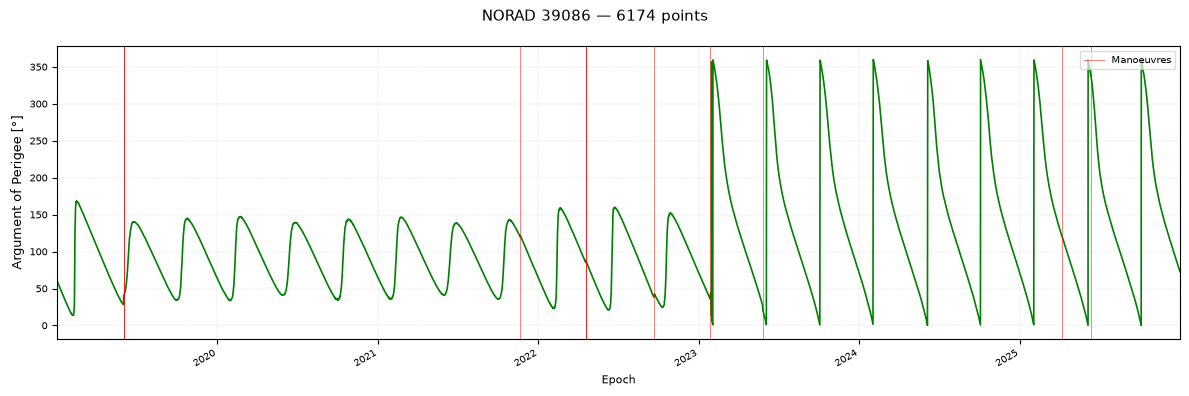

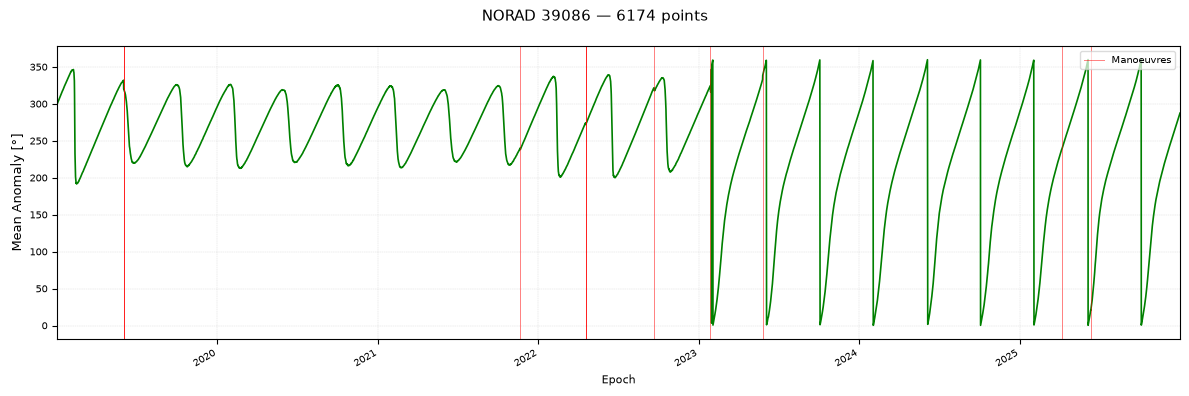

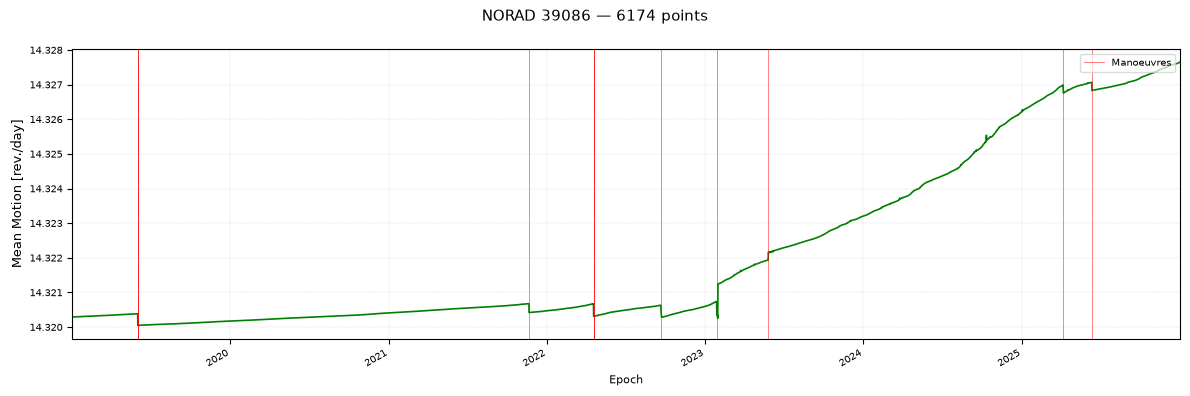

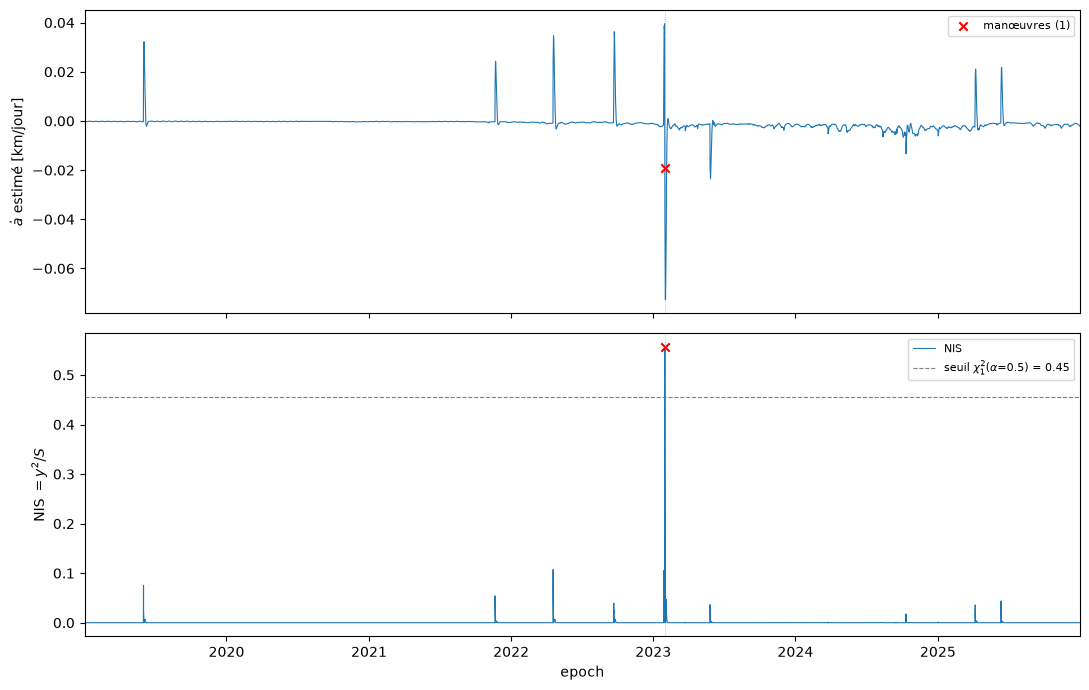

(array(['2019-01-01T19:51:13.250016', '2019-01-01T21:31:50.103552',
        '2019-01-02T22:41:02.891040', ..., '2025-12-31T12:19:08.228352',
        '2025-12-31T13:59:41.981856', '2025-12-31T22:22:30.751104'],
       shape=(6268,), dtype='datetime64[us]'),
 array([ 1.59088652e-05, -2.73883489e-04, -2.74039837e-04, ...,
        -2.15739595e-03, -2.19263451e-03, -2.18659108e-03], shape=(6268,)),
 array([0.00000000e+00, 9.14159517e-11, 6.24462267e-16, ...,
        2.09373376e-06, 2.43417581e-06, 5.36294990e-08], shape=(6268,)),
 array([3567]),
 np.float64(0.454936423119572))

In [5]:

path_TLE_srl = ROOT / "data" / "raw" / "SARAL_ALL_1783069319.365695.parquet"
norads = pl.scan_parquet(path_TLE_srl).select("norad").unique().sort("norad").collect().to_series().to_list()

norad = 39086
print(f"Norad {norad} in path : {norad in norads}")

path_maneuvers_srl = ROOT / "data" / "raw" / "srl_man_ILRS.parquet"
df_man = pl.scan_parquet(path_maneuvers_srl).collect()

maneuvers_dates= df_man.select('maneuver_start').to_series().to_list()

for param in ['sma', 'eccentricity', 'inclination', 'raan', 'arg_perigee', 'mean_anomaly', 'mean_motion']:
    fig = plot_time_series(path_TLE_srl, norad, param, maneuvers=maneuvers_dates)
    fig.savefig(FIG_DIR / f"srl_{param}.png", dpi=150, bbox_inches="tight")


## on retest rapidement notre filtre Kalman.
from maneuver_detection.discrete_kalman_filter import kalman_filter_ordre_1, kalman_filter_ordre_2, detect_kalman
import matplotlib.pyplot as plt

df_TLE_srl= (
    pl.scan_parquet(path_TLE_srl).filter(pl.col('norad') == norad)
    .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
    .sort('epoch').collect()
    )

detect_kalman(df_TLE_srl, ordre=1, var_Q = 0.013, r=0.1, alpha=0.5 )
plt.gcf().savefig(FIG_DIR / "srl_detect_kalman.png", dpi=150, bbox_inches="tight")

La base de donnée ILRS ne fournit que des données de satellites en orbite basse. On voit que le semi-grand axe est souvent le meilleur moyen de détecter des manoeuvres visuellement, d'où la pertinence de mettre en place des algos de détection basé sur cette métrique. 

# Quel type de manoeuvre ? 

Une variation de demi-grand axe $a$ est lié à une varition de la vitesse transverse $\Delta v _u$ : on a grossièrement : 
$$
\Delta a = \dfrac{2}{n} \Delta v_u
$$

Essayons de vérifier cette loi pour CryoSat 2: 


Norad 36508 in path : True
Filtre Kalman 1 appliqué...


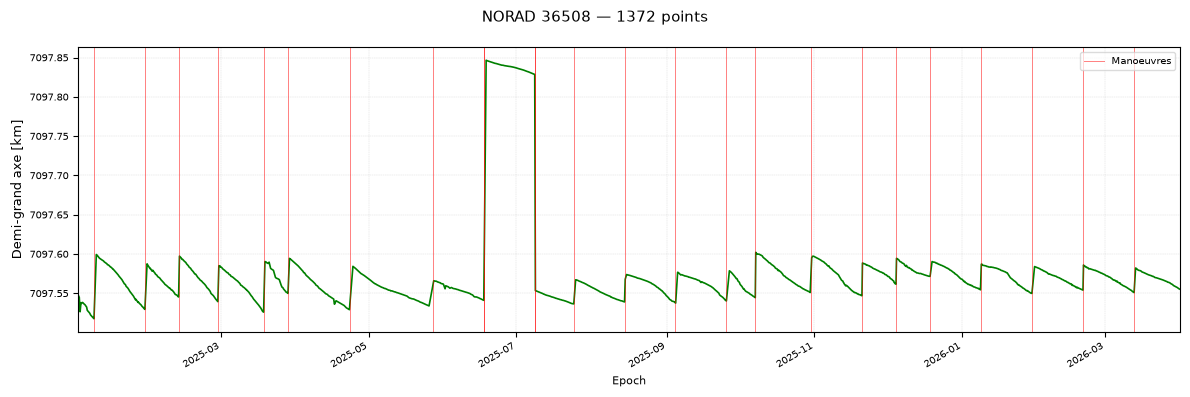

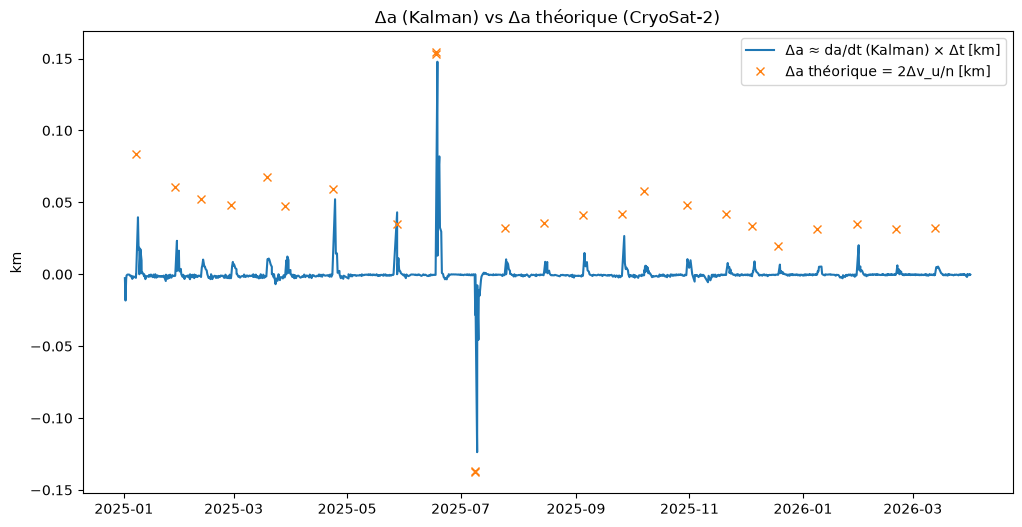

In [6]:

path_TLE_cs2 = ROOT / "data" / "raw" / "CRYOSAT_ESA_1783006097.0149062.parquet"
norads = pl.scan_parquet(path_TLE_cs2).select("norad").unique().sort("norad").collect().to_series().to_list()

norad = 36508
print(f"Norad {norad} in path : {norad in norads}")

path_maneuvers_cs2 = ROOT / "data" / "raw" / "cs2_man_ILRS.parquet"
df_man = pl.scan_parquet(path_maneuvers_cs2).collect()

maneuvers_dates= df_man.select('maneuver_start').to_series().to_list()

df_TLE= (
    pl.scan_parquet(path_TLE_cs2).filter(pl.col('norad') == norad)
    .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
    .sort('epoch').collect()
    )

## On plot la série du demi-grand axe avec les manoeuvres
plot_time_series(path_TLE_cs2,norad, 'sma', maneuvers=maneuvers_dates)

## On plot les variations du demi-grand axe (filtre Kalman) face à Δa théorique = (2/n) Δv_u

import numpy as np
import matplotlib.pyplot as plt

# On calcule des valeurs filtrées des variationsd de a 
residus, nis, a_dot = kalman_filter_ordre_1(df_TLE, r = 0.1)

# a_dot n'a que n-1 valeurs (une par transition k-1 -> k), aligné sur epoch[1:]
epoch = df_TLE['epoch'][1:]

epoch_lo, epoch_hi = epoch.min(), epoch.max()

df_man_in_range = df_man.filter(pl.col('burn_epoch').is_between(epoch_lo, epoch_hi))

burn_epoch = df_man_in_range['burn_epoch']
dv_t_km_j = df_man_in_range['dv_t'] * 86400 / 1000   # m/s -> km/j
n_rad_j = df_TLE['mean_motion'].mean() * 2 * np.pi 
delta_a_th = 2 * dv_t_km_j  / n_rad_j   # en km

delta_t = np.diff(df_TLE['epoch'].to_numpy()) / np.timedelta64(1, "D")
delta_a_approx = a_dot * delta_t
fig, ax = plt.subplots(figsize = (12,6))
ax.plot(epoch, delta_a_approx, color="tab:blue", label="Δa ≈ da/dt (Kalman) × Δt [km]")
ax.plot(burn_epoch, delta_a_th, color="tab:orange", marker="x", linestyle="None",
        label="Δa théorique = 2Δv_u/n [km]")
ax.set_ylabel("km")
ax.legend(loc="upper right")
plt.title("Δa (Kalman) vs Δa théorique (CryoSat-2)")
fig.savefig(FIG_DIR / "cs2_delta_a_kalman_vs_theorique.png", dpi=150, bbox_inches="tight")
plt.show()


## Testons sur ENVISAT 
Ce n'est pas un très bon exemple, car Envisat n'a été que très peu maneuvré sur la période retenue, avec principalement seulement deux manoeuvres fin 2010.


Filtre Kalman 2 appliqué...


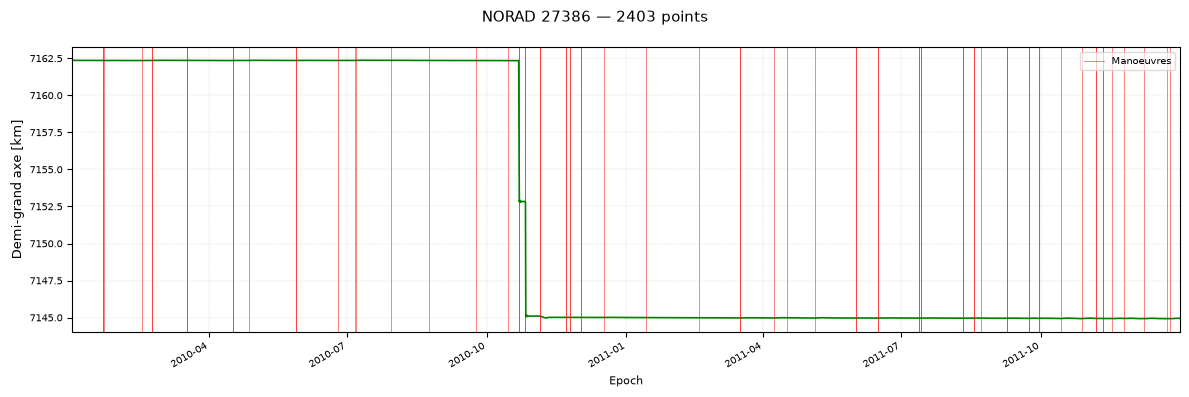

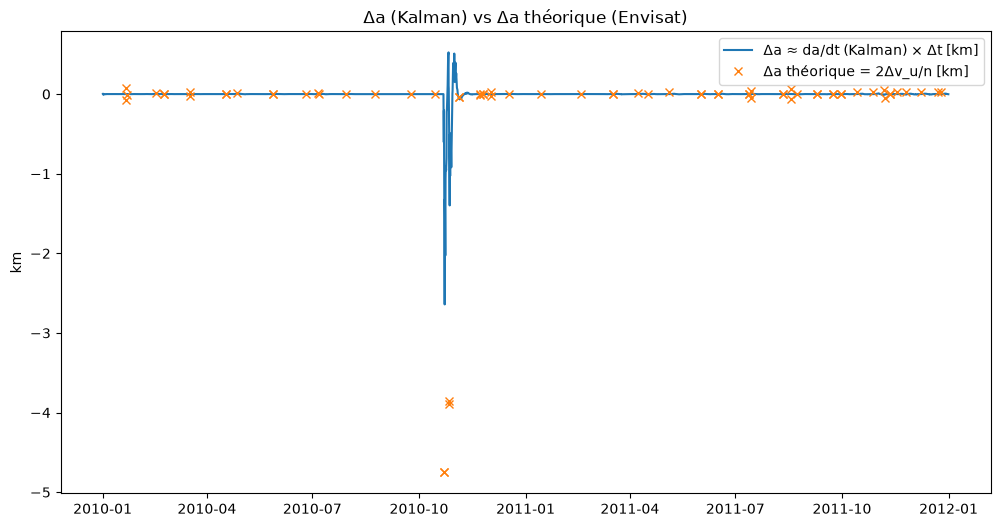

In [7]:

path_man_en1 = ROOT / "data" / "raw" / "en1_man_ILRS.parquet"
df_man_en1 = pl.scan_parquet(path_man_en1).collect()

norad = 27386

maneuvers_dates = df_man_en1.select('maneuver_start').to_series().to_list()

path_TLE_en1 = ROOT / "data" / "raw"  / "ENVISAT_ALL_1783068650.78004.parquet"

maneuvers_dates= df_man_en1.select('maneuver_start').to_series().to_list()

df_TLE= (
    pl.scan_parquet(path_TLE_en1).filter(pl.col('norad') == norad)
    .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
    .sort('epoch').collect()
    )

## On plot la série du demi-grand axe avec les manoeuvres
plot_time_series(path_TLE_en1,norad, 'sma', maneuvers=maneuvers_dates)

## On plot les variations du demi-grand axe (filtre Kalman) face à Δa théorique = (2/n) Δv_u

import numpy as np
import matplotlib.pyplot as plt

# On calcule des valeurs filtrées des variationsd de a 
residus, nis, a_dot = kalman_filter_ordre_2(df_TLE, var_Q = 0.013, r = 0.5 )

# a_dot n'a que n-1 valeurs (une par transition k-1 -> k), aligné sur epoch[1:]
epoch = df_TLE['epoch'][1:]

epoch_lo, epoch_hi = epoch.min(), epoch.max()

df_man_in_range = df_man_en1.filter(pl.col('burn_epoch').is_between(epoch_lo, epoch_hi))

burn_epoch = df_man_in_range['burn_epoch']
dv_t_km_j = df_man_in_range['dv_t'] * 86400 / 1000   # m/s -> km/j
n_rad_j = df_TLE['mean_motion'].mean() * 2 * np.pi 
delta_a_th = 2 * dv_t_km_j  / n_rad_j   # en km

delta_t = np.diff(df_TLE['epoch'].to_numpy()) / np.timedelta64(1, "D")
delta_a_approx = a_dot * delta_t
fig, ax = plt.subplots(figsize = (12,6))
ax.plot(epoch, delta_a_approx, color="tab:blue", label="Δa ≈ da/dt (Kalman) × Δt [km]")
ax.plot(burn_epoch, delta_a_th, color="tab:orange", marker="x", linestyle="None",
        label="Δa théorique = 2Δv_u/n [km]")
ax.set_ylabel("km")
ax.legend(loc="upper right")
plt.title("Δa (Kalman) vs Δa théorique (Envisat)")
fig.savefig(FIG_DIR / "en1_delta_a_kalman_vs_theorique.png", dpi=150, bbox_inches="tight")
plt.show()


## Test sur Sentinel 3B

Filtre Kalman 2 appliqué...


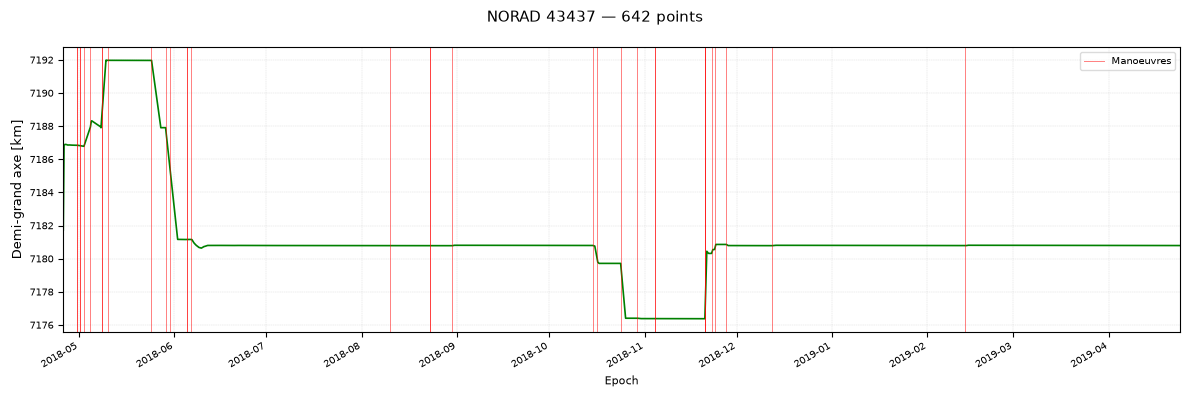

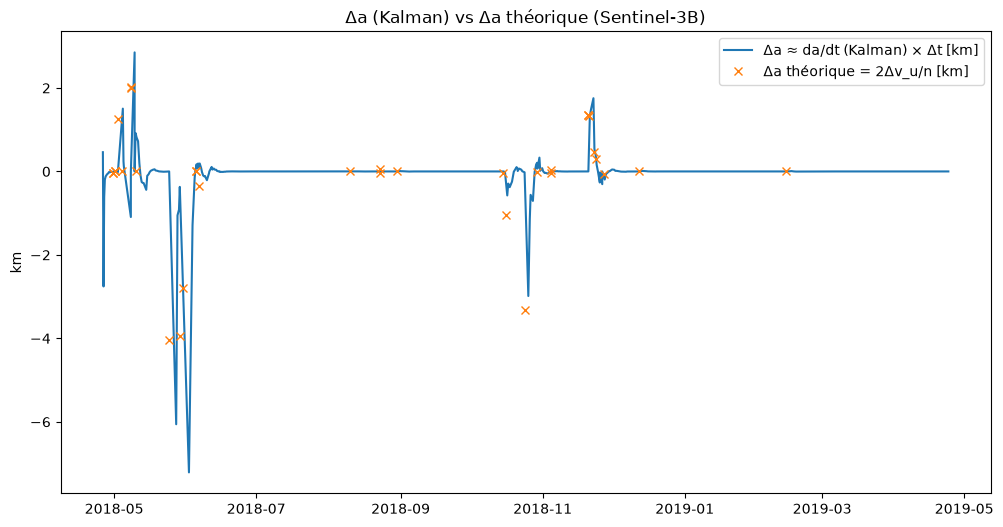

In [8]:

path_man_s3b = ROOT / "data" / "raw" / "s3b_man_ILRS.parquet"
df_man_s3b = pl.scan_parquet(path_man_s3b).collect()

norad = 43437

maneuvers_dates = df_man_s3b.select('maneuver_start').to_series().to_list()

path_TLE_s3b = ROOT / "data" / "raw"  / "SENTINEL_ALL_1783007466.119748.parquet"

maneuvers_dates= df_man_s3b.select('maneuver_start').to_series().to_list()

df_TLE= (
    pl.scan_parquet(path_TLE_s3b).filter(pl.col('norad') == norad)
    .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
    .sort('epoch').collect()
    )

## On plot la série du demi-grand axe avec les manoeuvres
plot_time_series(path_TLE_s3b,norad, 'sma', maneuvers=maneuvers_dates)

## On plot les variations du demi-grand axe (filtre Kalman) face à Δa théorique = (2/n) Δv_u

import numpy as np
import matplotlib.pyplot as plt

# On calcule des valeurs filtrées des variationsd de a 
residus, nis, a_dot = kalman_filter_ordre_2(df_TLE, var_Q = 0.013, r = 0.1 )

# a_dot n'a que n-1 valeurs (une par transition k-1 -> k), aligné sur epoch[1:]
epoch = df_TLE['epoch'][1:]

epoch_lo, epoch_hi = epoch.min(), epoch.max()

df_man_in_range = df_man_s3b.filter(pl.col('burn_epoch').is_between(epoch_lo, epoch_hi))

burn_epoch = df_man_in_range['maneuver_start']

dv_t_km_j = df_man_in_range['dv_t'] * 86400 / 1000   # m/s -> km/j
n_rad_j = df_TLE['mean_motion'].mean() * 2 * np.pi 
delta_a_th = 2 * dv_t_km_j  / n_rad_j   # en km

delta_t = np.diff(df_TLE['epoch'].to_numpy()) / np.timedelta64(1, "D")
delta_a_approx = a_dot * delta_t
fig, ax = plt.subplots(figsize = (12,6))
ax.plot(epoch, delta_a_approx, color="tab:blue", label="Δa ≈ da/dt (Kalman) × Δt [km]")
ax.plot(burn_epoch, delta_a_th, color="tab:orange", marker="x", linestyle="None",
        label="Δa théorique = 2Δv_u/n [km]")
ax.set_ylabel("km")
ax.legend(loc="upper right")
plt.title("Δa (Kalman) vs Δa théorique (Sentinel-3B)")
fig.savefig(FIG_DIR / "s3b_delta_a_kalman_vs_theorique.png", dpi=150, bbox_inches="tight")
plt.show()


## Test sur SARAL 
 

Filtre Kalman 1 appliqué...


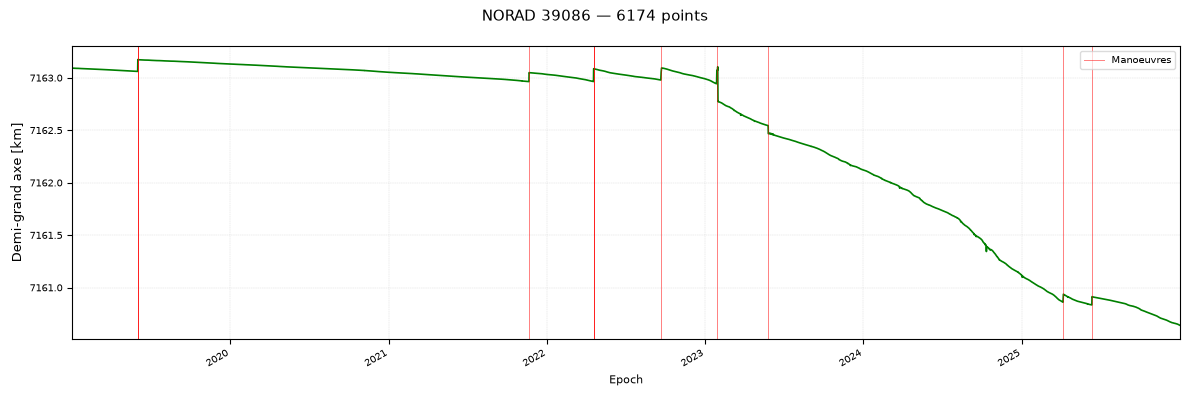

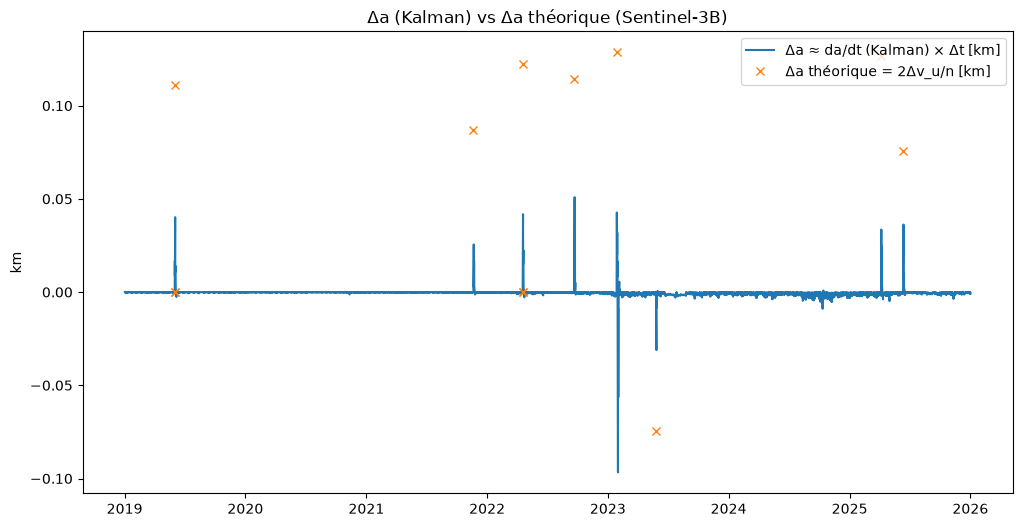

In [9]:

path_man_srl = ROOT / "data" / "raw" / "srl_man_ILRS.parquet"

df_man_srl = pl.scan_parquet(path_man_srl).collect()

norad = 39086

maneuvers_dates = df_man_srl.select('maneuver_start').to_series().to_list()

path_TLE_srl = ROOT / "data" / "raw" / "SARAL_ALL_1783069319.365695.parquet"

maneuvers_dates= df_man_srl.select('maneuver_start').to_series().to_list()

df_TLE= (
    pl.scan_parquet(path_TLE_srl).filter(pl.col('norad') == norad)
    .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
    .sort('epoch').collect()
    )

## On plot la série du demi-grand axe avec les manoeuvres
plot_time_series(path_TLE_srl,norad, 'sma', maneuvers=maneuvers_dates)

## On plot les variations du demi-grand axe (filtre Kalman) face à Δa théorique = (2/n) Δv_u

import numpy as np
import matplotlib.pyplot as plt

# On calcule des valeurs filtrées des variationsd de a 
residus, nis, a_dot = kalman_filter_ordre_1(df_TLE, var_Q = 0.13, r = 0.1 )

# a_dot n'a que n-1 valeurs (une par transition k-1 -> k), aligné sur epoch[1:]
epoch = df_TLE['epoch'][1:]

epoch_lo, epoch_hi = epoch.min(), epoch.max()

df_man_in_range = df_man_srl.filter(pl.col('burn_epoch').is_between(epoch_lo, epoch_hi))

burn_epoch = df_man_in_range['burn_epoch']

dv_t_km_j = df_man_in_range['dv_t'] * 86400 / 1000   # m/s -> km/j
n_rad_j = df_TLE['mean_motion'].mean() * 2 * np.pi 
delta_a_th = 2 * dv_t_km_j  / n_rad_j   # en km

delta_t = np.diff(df_TLE['epoch'].to_numpy()) / np.timedelta64(1, "D")
delta_a_approx = a_dot * delta_t
fig, ax = plt.subplots(figsize = (12,6))
ax.plot(epoch, delta_a_approx, color="tab:blue", label="Δa ≈ da/dt (Kalman) × Δt [km]")
ax.plot(burn_epoch, delta_a_th, color="tab:orange", marker="x", linestyle="None",
        label="Δa théorique = 2Δv_u/n [km]")
ax.set_ylabel("km")
ax.legend(loc="upper right")
plt.title("Δa (Kalman) vs Δa théorique (SARAL)")
fig.savefig(FIG_DIR / "srl_delta_a_kalman_vs_theorique.png", dpi=150, bbox_inches="tight")
plt.show()


La loi théorique, dérivée des équations de Gauss dans le cas d'orbite quasi-circulaire (ici $ e  \sim 10^{-4}$ ), est bien vérifiée.
L'écart entre les pics et la valeurs théoriques de $\Delta a$ s'explique par le choix pour l'instant plus ou moins arbitraire des paramètres du filtre Kalman, notamment $r$, l'incertitude de mesure aléatoire sur le demi grand axe, qui fait varier plus ou moins l'intensité des pics.

On voit que $\Delta v_{transverse}  = \dfrac{2}{n} \Delta v_{u,mesuré}$ et $\Delta a _{approx} \sim \dot{a}_{Kalman} \Delta t$ sont effectivement du même ordre de grandeur

## Type de manoeuvres 

Ces manoeuvres résultant d'une variation de $\Delta v_{transverse} $ correspondent à des manoeuvres in plane de replacement du satellite. On peut quantifier ça en remontant directement à $\Delta v_{transverse} $ depuis une mesure d'une variation $\Delta a$ avec une méthode de détection de manoeuvre bien calibrée. 

### Manoeuvres purement in plane ? 

Dans un premier temps, on voit que les manoeuvres concordent avec non seulement des variations du demi grand axe $a$, mais aussi de l'inclinaison et du perigée. Cela traduit donc des manoeuvres out-plane.

On va pour confirmer cela regarder les données directement : on va tracer, pour chaque maneouvre de CryoSat 2, les trois composantes de la variation de vitesse.


Norad 36508 in path : True


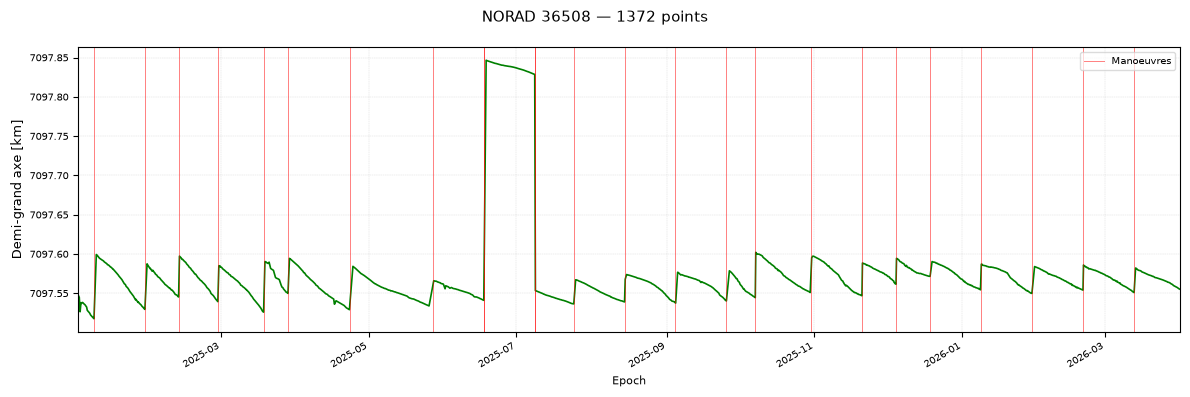

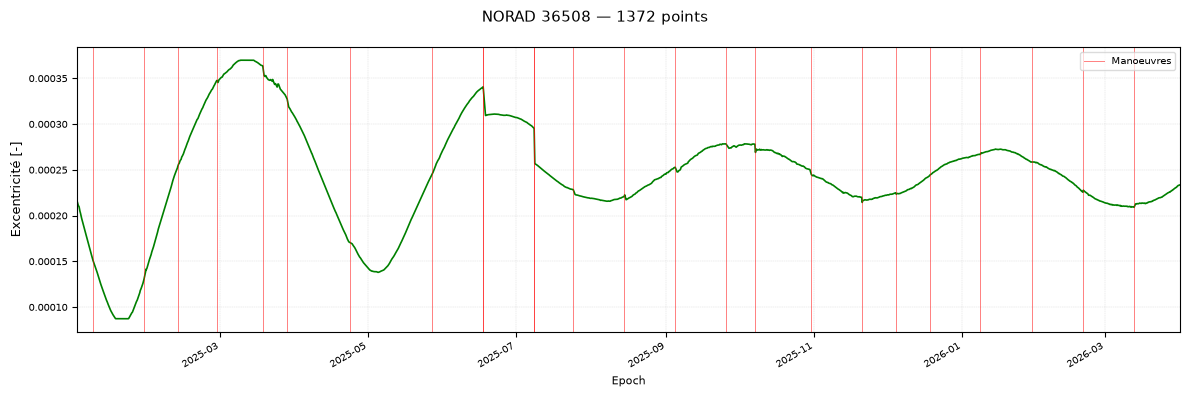

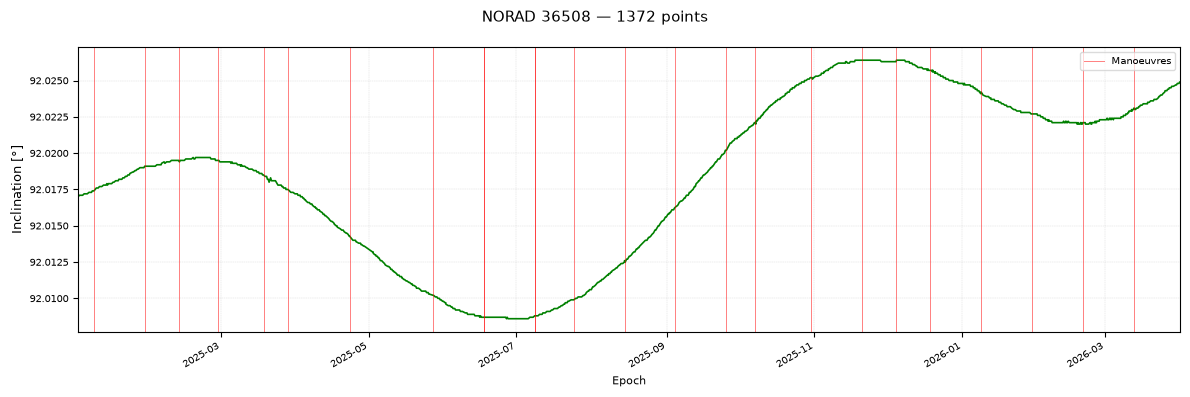

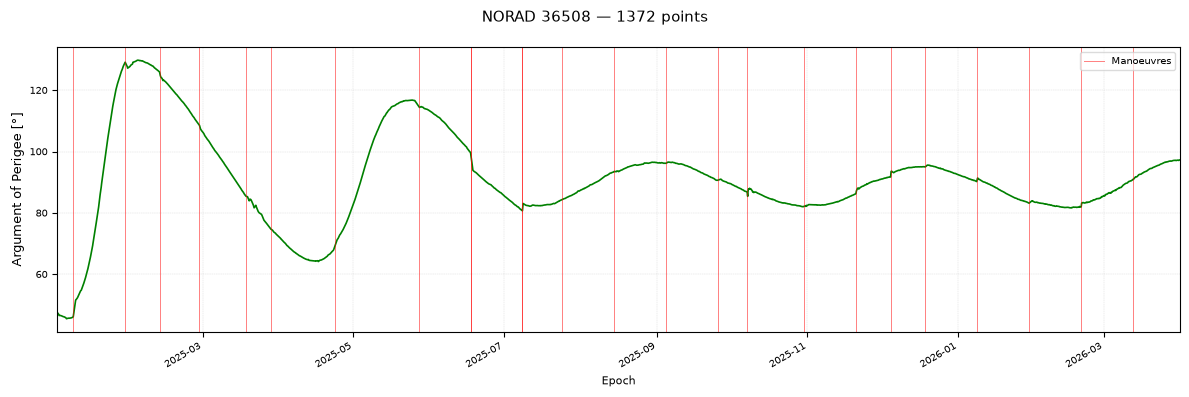

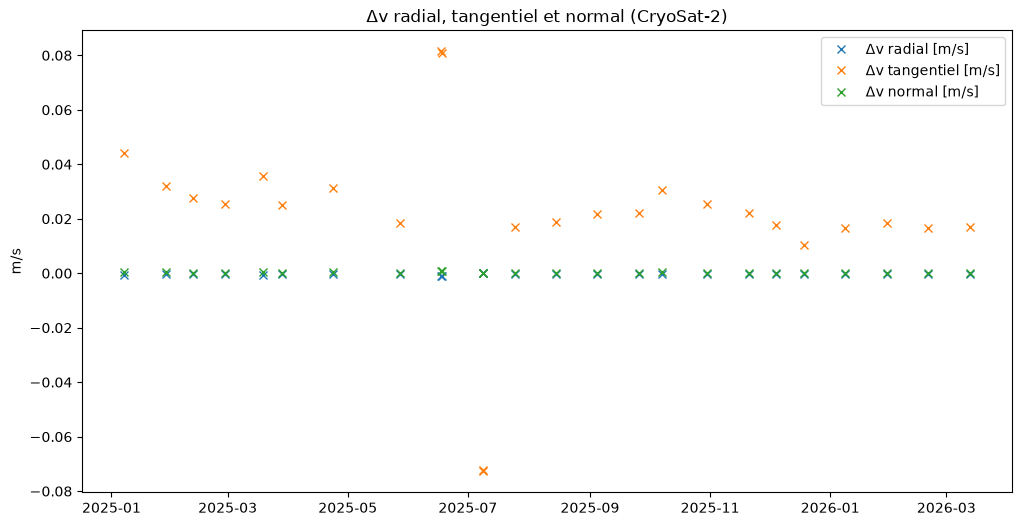

In [10]:

path_TLE_cs2 = ROOT / "data" / "raw" / "CRYOSAT_ESA_1783006097.0149062.parquet"
norads = pl.scan_parquet(path_TLE_cs2).select("norad").unique().sort("norad").collect().to_series().to_list()

norad = 36508
print(f"Norad {norad} in path : {norad in norads}")

path_maneuvers_cs2 = ROOT / "data" / "raw" / "cs2_man_ILRS.parquet"
df_man = pl.scan_parquet(path_maneuvers_cs2).collect()

maneuvers_dates= df_man.select('maneuver_start').to_series().to_list()

df_TLE= (
    pl.scan_parquet(path_TLE_cs2).filter(pl.col('norad') == norad)
    .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
    .sort('epoch').collect()
    )

## On plot la série du demi-grand axe avec les manoeuvres
plot_time_series(path_TLE_cs2,norad, 'sma', maneuvers=maneuvers_dates)
plot_time_series(path_TLE_cs2,norad, 'eccentricity', maneuvers=maneuvers_dates)
plot_time_series(path_TLE_cs2,norad, 'inclination', maneuvers=maneuvers_dates)
plot_time_series(path_TLE_cs2,norad, 'arg_perigee', maneuvers=maneuvers_dates)


import numpy as np
import matplotlib.pyplot as plt


epoch = df_TLE['epoch'][1:]

epoch_lo, epoch_hi = epoch.min(), epoch.max()

df_man_in_range = df_man.filter(pl.col('burn_epoch').is_between(epoch_lo, epoch_hi))
burn_epoch = df_man_in_range['burn_epoch']

dv_r = df_man_in_range['dv_r']  
dv_t = df_man_in_range['dv_t'] 
dv_n = df_man_in_range['dv_n'] 
fig, ax = plt.subplots(figsize = (12,6))

ax.plot(burn_epoch, dv_r, color="tab:blue", marker = "x", linestyle="None",
        label="Δv radial [m/s]")
ax.plot(burn_epoch, dv_t, color="tab:orange", marker="x", linestyle="None",
        label="Δv tangentiel [m/s]")
ax.plot(burn_epoch, dv_n, color="tab:green", marker="x", linestyle="None",
        label="Δv normal [m/s]")
ax.set_ylabel("m/s")   
ax.legend(loc="upper right")
plt.title("Δv radial, tangentiel et normal (CryoSat-2)")
fig.savefig(FIG_DIR / "cs2_dv_composantes.png", dpi=150, bbox_inches="tight")
plt.show()

Les manoeuvres sont donc purement transverses pour Cryosat2, donc purement in-plane

## Variations des vitesses pour Sentinel 3b  

Norad 43437 in path : True


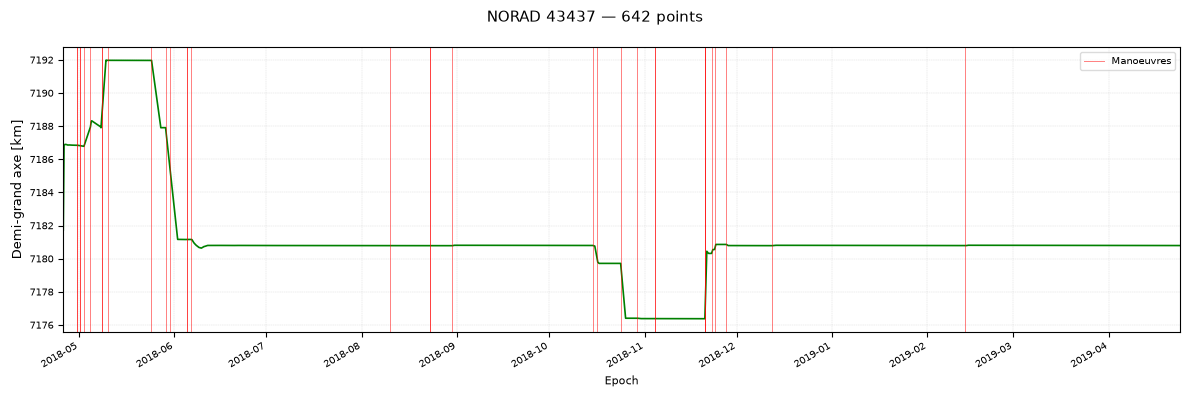

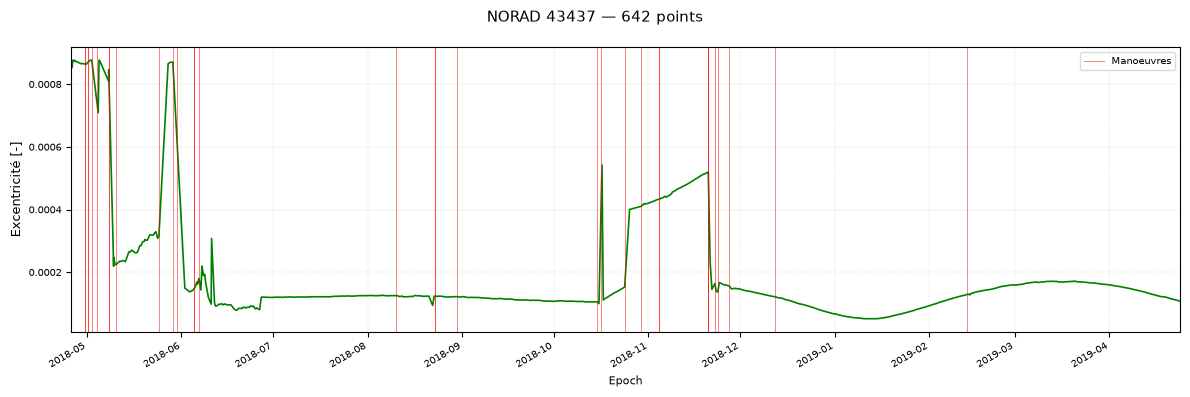

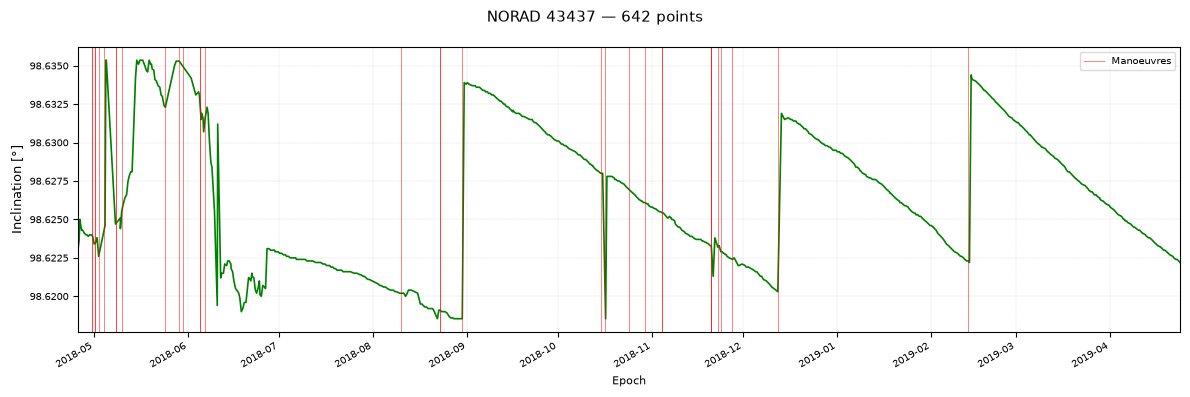

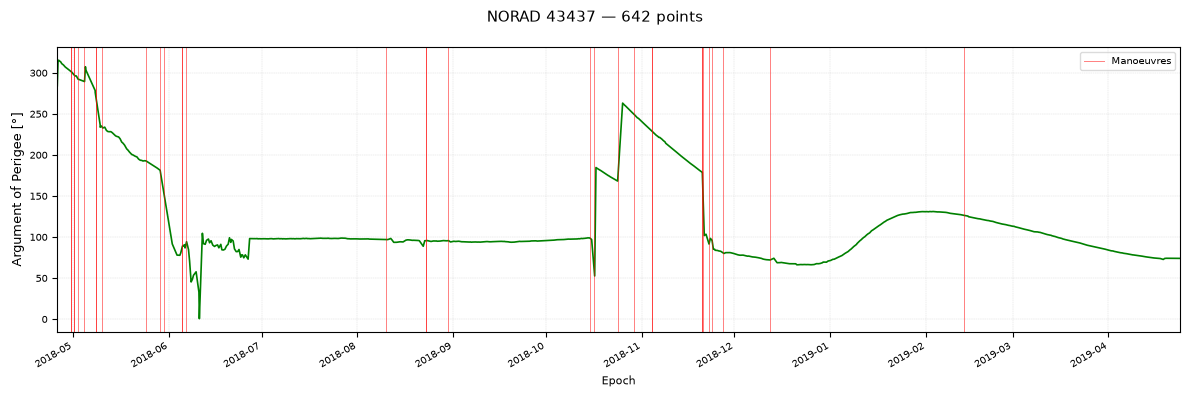

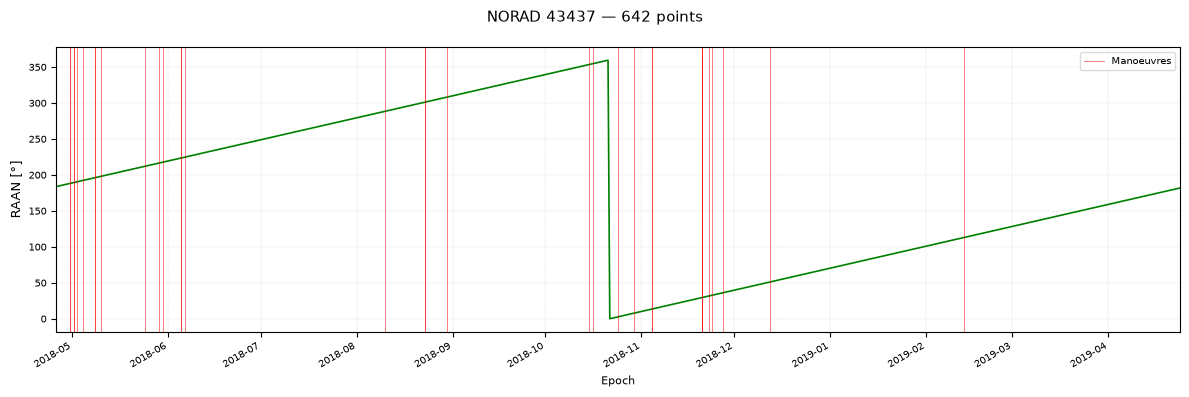

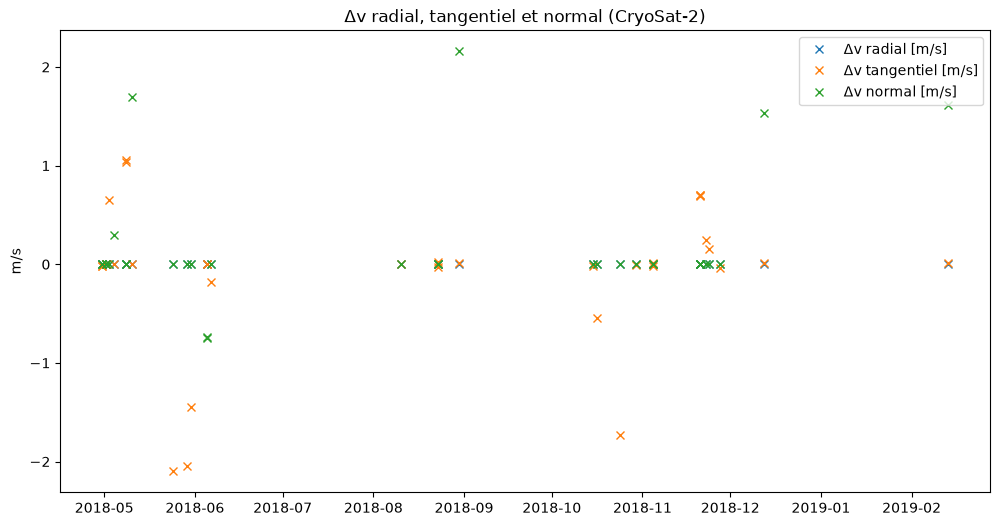

In [11]:

path_TLE_s3b = ROOT / "data" / "raw"  / "SENTINEL_ALL_1783007466.119748.parquet"
norads = pl.scan_parquet(path_TLE_s3b).select("norad").unique().sort("norad").collect().to_series().to_list()

norad = 43437
print(f"Norad {norad} in path : {norad in norads}")

path_maneuvers_s3b = ROOT / "data" / "raw" / "s3b_man_ILRS.parquet"
df_man = pl.scan_parquet(path_maneuvers_s3b).collect()

maneuvers_dates= df_man.select('maneuver_start').to_series().to_list()

df_TLE= (
    pl.scan_parquet(path_TLE_s3b).filter(pl.col('norad') == norad)
    .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
    .sort('epoch').collect()
    )

## On plot la série du demi-grand axe avec les manoeuvres
plot_time_series(path_TLE_s3b,norad, 'sma', maneuvers=maneuvers_dates)
plot_time_series(path_TLE_s3b,norad, 'eccentricity', maneuvers=maneuvers_dates)
plot_time_series(path_TLE_s3b,norad, 'inclination', maneuvers=maneuvers_dates)
plot_time_series(path_TLE_s3b,norad, 'arg_perigee', maneuvers=maneuvers_dates)
plot_time_series(path_TLE_s3b,norad, 'raan', maneuvers=maneuvers_dates)


import numpy as np
import matplotlib.pyplot as plt


epoch = df_TLE['epoch'][1:]

epoch_lo, epoch_hi = epoch.min(), epoch.max()

df_man_in_range = df_man.filter(pl.col('maneuver_start').is_between(epoch_lo, epoch_hi))

burn_epoch = df_man_in_range['maneuver_start']

dv_r = df_man_in_range['dv_r']  
dv_t = df_man_in_range['dv_t'] 
dv_n = df_man_in_range['dv_n'] 
fig, ax = plt.subplots(figsize = (12,6))

ax.plot(burn_epoch, dv_r, color="tab:blue", marker = "x", linestyle="None",
        label="Δv radial [m/s]")
ax.plot(burn_epoch, dv_t, color="tab:orange", marker="x", linestyle="None",
        label="Δv tangentiel [m/s]")
ax.plot(burn_epoch, dv_n, color="tab:green", marker="x", linestyle="None",
        label="Δv normal [m/s]")
ax.set_ylabel("m/s")   
ax.legend(loc="upper right")
plt.title("Δv radial, tangentiel et normal (Sentinel-3B)")
fig.savefig(FIG_DIR / "s3b_dv_composantes.png", dpi=150, bbox_inches="tight")
plt.show()

Cette fois-ci, les manoeuvres ne sont pas purement transverse. On voit un qu'un certain nombre de manoeuvres possèdent une composante normale importante. Cette variation de vitesse normale crée une manoeuvre out-plane.

Cela se traduit a priori par des variations de l'inclinaison et de la RAAN. Voici l'équation de Gauss reliant une perturbation normale de la vitesse et une variation de l'inclinaison de l'ellipse : 

$$
\Delta i = \dfrac{r}{n a ^2} \cos (\omega + \nu ) \Delta v_ n  \quad; \quad \Delta \Omega = \dfrac{r}{n a ^2} \dfrac{\sin (\omega + \nu )}{\sin i} \Delta v_ n 
$$

$n = \dfrac{2 \pi}{T}$ est le mouvement moyen, $r \sim a $ la distance du foyer au satellite et $\nu$ l'anomalie vraie 

Cependant on ne voit ici aucun effet des manoeuvres sur le RAAN. 
On est ici dans le cas d'une orbite quasi-polaire : $$ i \sim 100° $$
Dans ce cas, la dérive de $\Omega$ liée au terme de perturbation du champ gravitationnel l'emporte :
En coordonnées sphériques, on a au premier ordre :  
$$
U_{Terre}(r, \lambda, \theta) = U_0 + U_{J_2} = -\dfrac{\mu}{r}( 1  - \dfrac{J_2}{2} (\dfrac{R_T}{r})^2 (3 \sin ^2 \lambda - 1))
$$

Et le terme $U_{J_2}$ induit une dérive de $\Omega$ : 

$$
\dot{\Omega}_{J_2 } = -\dfrac{3}{2} J_2 (\dfrac{R_T}{r})^2  n \cos i \sim 1° / \text{jour}
$$

Tandis que les varitations due à la manoeuvres sont de l'ordre de $ 0.01° / \text{jour}$


REMARQUE IMPORTANTE : Tout cela n'est plus vrai pour des orbites à faible inclinaison : Si $ i \sim 0° $, $\Omega$ varie en $\dfrac{1}{\sin i }$ et devient un canal d'observation valable (La discontinuité des paramètres angulaires nécessite alors d'ailleurs un changement de coordonnées vers les coordonnées equinoxales).  


Pour analyser les manoeuvres out-plane, on se base donc sur les variations de l'inclinaison, et on teste la loi de Gauss comme précédemment pour le demi grand axe.




Norad 43437 in path : True
Filtre Kalman 1 appliqué...
Filtre Kalman 1 appliqué...


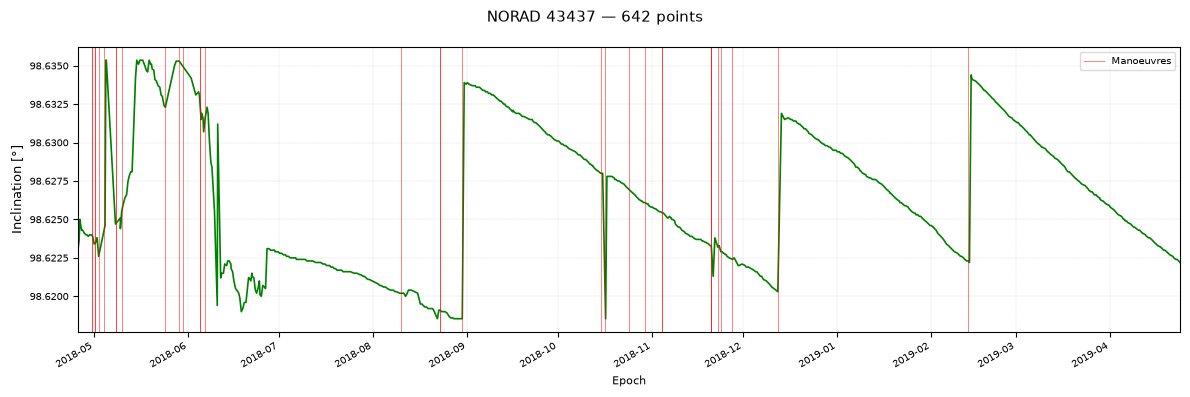

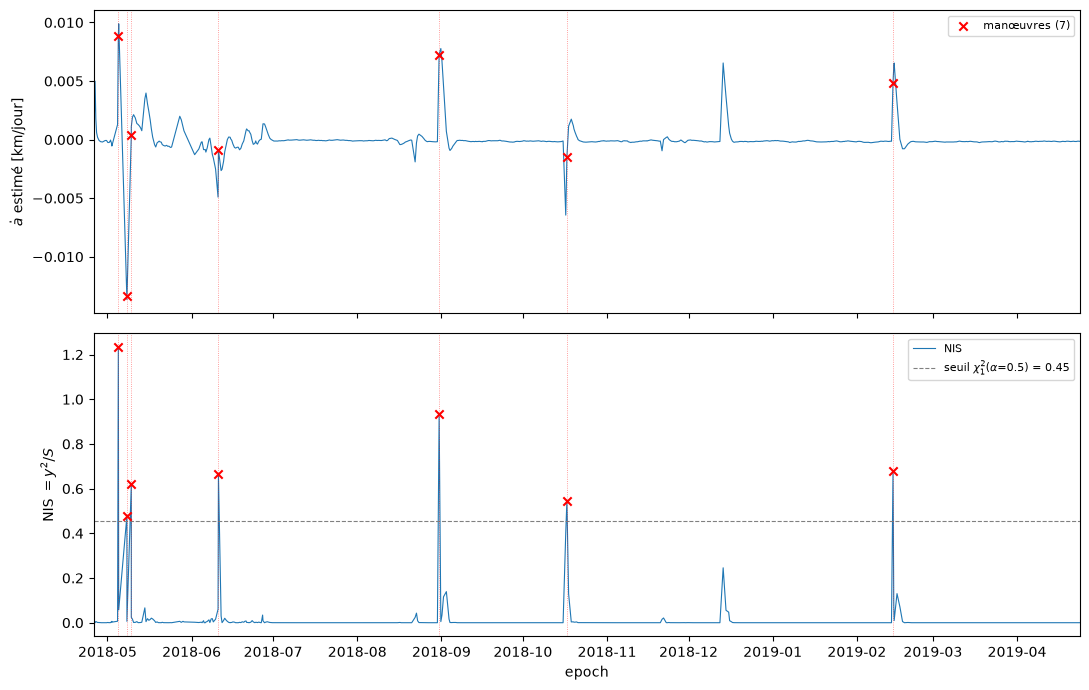

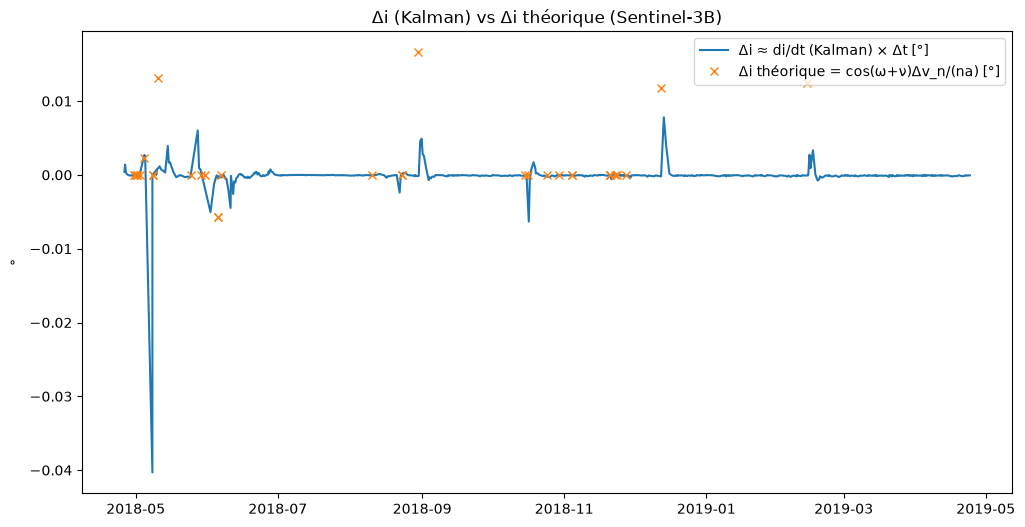

In [12]:

path_TLE_s3b = ROOT / "data" / "raw"  / "SENTINEL_ALL_1783007466.119748.parquet"
norads = pl.scan_parquet(path_TLE_s3b).select("norad").unique().sort("norad").collect().to_series().to_list()

norad = 43437
print(f"Norad {norad} in path : {norad in norads}")

path_maneuvers_s3b = ROOT / "data" / "raw" / "s3b_man_ILRS.parquet"
df_man = pl.scan_parquet(path_maneuvers_s3b).collect()

maneuvers_dates= df_man.select('maneuver_start').to_series().to_list()

df_TLE= (
    pl.scan_parquet(path_TLE_s3b).filter(pl.col('norad') == norad)
    .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
    .sort('epoch').collect()
    )

## On plot la série de l'inclinaison avec les manoeuvres
plot_time_series(path_TLE_s3b,norad, 'inclination', maneuvers=maneuvers_dates)



import numpy as np
import matplotlib.pyplot as plt

# On calcule des valeurs filtrées des variations de i , il faut adapter r = bruit de mesure sur i, bcp plus petit que pour a 
residus, nis, i_dot = kalman_filter_ordre_1(df_TLE, var_Q = 0.00013, r = 0.0001, metrique = 'inclination')

# On affiche aussi le résultat du filtage. 
detect_kalman(df_TLE, ordre=1, var_Q = 0.00013, r=0.0001, alpha=0.5, metrique = 'inclination')


# i_dot n'a que n-1 valeurs (une par transition k-1 -> k), aligné sur epoch[1:]
epoch = df_TLE['epoch'][1:]

epoch_lo, epoch_hi = epoch.min(), epoch.max()

df_man_in_range = df_man.filter(pl.col('burn_epoch').is_between(epoch_lo, epoch_hi)).sort('burn_epoch')

burn_epoch = df_man_in_range['burn_epoch']

## Il faut alors calculer tous les paramètres orbitaux nécessaires au delta(i) théorique :
# anomalie moyenne, semi grand axe, argument du périgée, anomalie vraie, à l'instant du burn.



dv_n_km_j = df_man_in_range['dv_n'] * 86400 / 1000   # m/s -> km/j

df_burns_join = df_man_in_range.select('burn_epoch').join_asof(
    df_TLE.select('epoch', 'sma', 'mean_motion', 'arg_perigee', 'mean_anomaly').sort('epoch'),
    left_on='burn_epoch', right_on='epoch', strategy='nearest'
)
u_rad = np.deg2rad(df_burns_join['arg_perigee'] + df_burns_join['mean_anomaly'])  # ω+ν, ν≈M (orbite quasi-circulaire)
n_rad_j_burn = df_burns_join['mean_motion'] * 2 * np.pi
a_burn = df_burns_join['sma']  # en km

# Δi = cos(ω+ν)/(n a) Δv_n  (Gauss, orbite quasi-circulaire r≈a), converti en degrés
delta_i_th = np.rad2deg(
    np.cos(u_rad).to_numpy() * dv_n_km_j.to_numpy() / (n_rad_j_burn.to_numpy() * a_burn.to_numpy())
)

delta_t = np.diff(df_TLE['epoch'].to_numpy()) / np.timedelta64(1, "D")

## On calcule Δi approximatif à partir de i_dot (filtre Kalman) et Δt
delta_i_approx = i_dot * delta_t

## Affichage de la figure
fig, ax = plt.subplots(figsize = (12,6))
ax.plot(epoch, delta_i_approx, color="tab:blue", label="Δi ≈ di/dt (Kalman) × Δt [°]")
ax.plot(burn_epoch, delta_i_th, color="tab:orange", marker="x", linestyle="None",
        label="Δi théorique = cos(ω+ν)Δv_n/(na) [°]")
ax.set_ylabel("°")
ax.legend(loc="upper right")
plt.title("Δi (Kalman) vs Δi théorique (Sentinel-3B)")
fig.savefig(FIG_DIR / "s3b_delta_i_kalman_vs_theorique.png", dpi=150, bbox_inches="tight")
plt.show()


On remarque déjà que le filtrage de $\Delta i $ est une réussite (bien qu'il faille encore calibrer convenablement les paramètres du filtre pour bien filtrer l'inclinsaison, c'est un autre sujet). Au moins les pics sont définis au niveau des manoeuvres (ou groupe de manoeuvres) réelles.
Encore une fois la relation est vérifiée en terme d'ordre de grandeur. On a maintenant un moyen de détecter des manoeuvres out-plane explicitement, via un filtrage sur l'inclinaison pour des orbites LEO non-equatoriales.
